# Notebook 1: From one winning label to full vote distributions

**The question.** If the words of a text stay exactly the same but we say who wrote it, does the
emotion people read into it change? And do LLMs react the way people do?

**How to read this notebook**
- Read the text cells first. The code cells can be skipped on a first read: every result is
  explained right under it.
- **All the code is here.** Nothing is hidden in another file. Each piece of code appears just
  before the first result that uses it.
- New to the terms (vote shares, shift, chance shuffles, p-value, Holm)? Read Part 1 of
  `Presentation_Script_Guided_Analysis.pdf` first.

**The plan**

| Part | What happens |
|---|---|
| A | Analyse everything the **old way**: keep only the winning emotion per text |
| B | Show what that old way **throws away** |
| C | Redo the same questions **keeping all the votes** (vote-share vectors) |
| D | **Compare** the two sets of answers |

**The four hypotheses (plain words)**

| | Prediction |
|---|---|
| H1 | People read ambiguous texts differently when told who wrote them; clear texts hardly change |
| H2 | LLMs change their answer when told who wrote the text |
| H3 | The author matters more for author-relevant texts than for author-independent texts |
| H4 | LLMs move partly in the same direction as people, but by a different amount |

Not every hypothesis has to be confirmed; the point is to test them.

## Step 0: Setup

Libraries, folders and three small helpers (`explain`, `table`, `finish`) that show and save
results. Nothing is calculated here.

In [1]:
# ---- Housekeeping: libraries, folders and display helpers. Nothing is calculated here. ----
from pathlib import Path
from itertools import combinations, product
import hashlib
import re
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
%matplotlib inline

# The project folder is the one that contains data/. This works whether Jupyter was started
# in the project folder or inside distribution_analysis_v1/.
ROOT = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
DATA = ROOT / 'data'
RESULTS = ROOT / 'results'          # every table and graph below is also saved here
RESULTS.mkdir(exist_ok=True)

plt.rcParams.update({'figure.dpi': 115, 'font.size': 11, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.titleweight': 'bold', 'axes.titlesize': 13,
                     'figure.figsize': (10, 5), 'savefig.bbox': 'tight'})
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 60)
pd.set_option('display.width', 150)


def explain(text):
    """Show a short explanation under a result."""
    display(Markdown(text))


def table(df, name, digits=3):
    """Save a table as results/<name>.csv and show it, rounded."""
    df.to_csv(RESULTS / (name + '.csv'), index=False)
    shown = df.round(digits).copy()
    # p-values keep 4 significant digits, so a very small p never shows as 0.
    for c in df.columns:
        if str(c).startswith('p_') or c in ['p_value', 'p_BH']:
            shown[c] = df[c].map(lambda x: f'{x:.4g}' if pd.notna(x) else '')
    display(shown)


def finish(fig, name):
    """Save a figure as results/<name>.png and show it."""
    fig.tight_layout()
    fig.savefig(RESULTS / (name + '.png'), dpi=170)
    plt.show()

## Step 1: The building blocks

Two ideas are used everywhere in this notebook.

**Vote shares.** Votes become percentages over the 11 emotions.
*anger, anger, sadness* → 67% anger, 33% sadness, 0% for everything else.

**Comparing two sets of votes** (`compare_votes`): for one text, the neutral votes against the
votes under one persona. It records:
- the **shift** (total variation, TV): how much of the vote share has to move to turn one set into
  the other. 0 = identical, 1 = completely different emotions. It is half of the summed
  differences, so nothing is counted twice;
- the **old-method label change**: did the winning emotion change? (ties go to the alphabetically
  first emotion);
- which emotions **appear** or **disappear**, and which of **five kinds of change** it is;
- the change in **spread** (entropy).

The small example at the end shows all of this on three made-up votes per side.

In [2]:
# The 11 emotions, always in this alphabetical order. Every vote-share vector uses this order.
E = ['anger', 'disgust', 'fear', 'guilt', 'joy', 'pride',
     'relief', 'sadness', 'shame', 'surprise', 'trust']
EI = {e: i for i, e in enumerate(E)}      # emotion -> position, e.g. EI['joy'] is 4

# The three text groups: short code names and display names.
CATS = ['unambiguous', 'author_independent', 'author_relevant']
CAT_NAMES = ['Unambiguous', 'Author-independent', 'Author-relevant']
CAT_NAME = dict(zip(CATS, CAT_NAMES))
POOL_TO_KEY = {'Unambiguous': 'unambiguous',
               'Author-Independent Ambiguous': 'author_independent',
               'Author-Relevant Ambiguous': 'author_relevant'}
COLORS = {'Human': '#177e89', 'LLM': '#d66b35'}

# How many random shuffles or resamples every test and error bar uses.
N_RANDOM = 10000

# Where each model's answer is stored in experiment_results_all.csv.
MODEL_COLS = {'OpenAI': 'ChatGPT_label_norm', 'Claude': 'Claude_label_norm',
              'Gemini': 'Gemini_label_norm', 'Qwen3': 'Qwen3_label_norm',
              'Gemma3': 'Gemma3_label_norm', 'Ministral': 'Ministral_label_norm',
              'Llama31': 'Llama31_label_norm'}
MODEL_RAW_COLS = {m: col.replace('_label_norm', '_label') for m, col in MODEL_COLS.items()}

In [3]:
def vec(votes):
    """Votes -> vote shares over the 11 emotions.
    votes is a list of emotion positions: anger, anger, sadness = [0, 0, 7]
    -> 0.667 anger, 0.333 sadness, 0 for the other nine emotions."""
    return np.bincount(votes, minlength=len(E)).astype(float) / len(votes)


def entropy(v):
    """How spread out a vote-share vector is (in 'nats').
    0 = everyone chose the same emotion; bigger = votes spread over more emotions."""
    v = np.asarray(v)
    safe = np.where(v > 0, v, 1)          # log(1) = 0, so emotions with no votes add nothing
    return -(safe * np.log(safe)).sum(axis=-1)


def cosine(a, b):
    """Direction similarity of two shift vectors: +1 same direction, 0 unrelated, -1 opposite.
    It is undefined (NaN) when either vector is all zeros, i.e. that side did not move."""
    lengths = np.linalg.norm(a, axis=-1) * np.linalg.norm(b, axis=-1)
    return np.divide((a * b).sum(axis=-1), lengths,
                     out=np.full_like(lengths, np.nan, dtype=float), where=lengths > 1e-12)


def compare_votes(a, b):
    """Compare the NEUTRAL votes a with the PERSONA votes b for one text.
    Returns every quantity the notebooks use for that one comparison."""
    p, q = vec(a), vec(b)                  # neutral shares, persona shares
    ps, qs = p > 0, q > 0                  # which emotions received at least one vote
    tp, tq = p == p.max(), q == q.max()    # the top emotion(s); more than one means a tie

    tv = np.abs(q - p).sum() / 2           # SHIFT (total variation): share of votes that must move
    gain = qs & ~ps                        # emotions that APPEAR under the persona
    loss = ps & ~qs                        # emotions that DISAPPEAR under the persona
    same_support = np.array_equal(ps, qs)  # exactly the same emotions present on both sides?
    same_top = np.array_equal(tp, tq)      # exactly the same top emotion(s) on both sides?

    # OLD METHOD: the selected label is the top emotion; a tie goes to the alphabetically first.
    w0, w1 = int(np.argmax(p)), int(np.argmax(q))
    # The same, but with ties broken by reverse alphabet (used to show that the tie rule matters).
    wr0 = len(E) - 1 - int(np.argmax(p[::-1]))
    wr1 = len(E) - 1 - int(np.argmax(q[::-1]))

    # The five kinds of change. Every comparison gets exactly one.
    if tv < 1e-12:
        change = 'No distribution change'
    elif same_support:
        change = 'Same emotions; proportions change'
    elif gain.any() and loss.any():
        change = 'Emotions appear AND disappear'
    elif gain.any():
        change = 'Emotions appear only'
    else:
        change = 'Emotions disappear only'

    moved = tv > 1e-12
    return dict(p=p, q=q, delta=q - p, neutral_votes=a, persona_votes=b,
                neutral_n=len(a), persona_n=len(b), winner0=w0, winner1=w1,
                flip=float(w0 != w1),                  # old method: did the label change?
                flip_reverse=float(wr0 != wr1), tv=tv,
                neutral_tie=tp.sum() > 1, persona_tie=tq.sum() > 1,
                same_top=same_top, same_support=same_support, gained=gain, lost=loss,
                gain_any=bool(gain.any()), loss_any=bool(loss.any()),
                n_gained=int(gain.sum()), n_lost=int(loss.sum()),
                same_support_change=bool(same_support and moved),
                hidden_label=bool(w0 == w1 and moved),         # moved, but same selected label
                hidden_top=bool(same_top and moved),           # moved, but same top emotion(s)
                strict_proportion=bool(same_top and same_support and moved),
                entropy_change=float(entropy(q) - entropy(p)), change=change)

In [4]:
# A tiny worked example: neutral = anger, anger, sadness; persona = anger, fear, fear.
demo = compare_votes(np.array([EI['anger'], EI['anger'], EI['sadness']]),
                     np.array([EI['anger'], EI['fear'], EI['fear']]))
print('neutral shares:', {e: round(float(s), 3) for e, s in zip(E, demo['p']) if s})
print('persona shares:', {e: round(float(s), 3) for e, s in zip(E, demo['q']) if s})
print('shift (TV)    :', round(demo['tv'], 3))
print('label changed :', bool(demo['flip']), f"({E[demo['winner0']]} -> {E[demo['winner1']]})")
print('kind of change:', demo['change'])

neutral shares: {'anger': 0.667, 'sadness': 0.333}
persona shares: {'anger': 0.333, 'fear': 0.667}
shift (TV)    : 0.667
label changed : True (anger -> fear)
kind of change: Emotions appear AND disappear


**Reading the example.** Anger falls from 67% to 33%, sadness from 33% to 0% and fear rises from
0% to 67%. The differences add up to 33 + 33 + 67 = 133 points; half of that is **67%**, the
shift. The winning label changed (anger → fear), fear appeared and sadness disappeared.

## Step 2: Load all the data

- **300 texts** (100 per group) from `sampled_texts.csv`.
- **Human votes**: about 3 people per version (neutral, persona A, persona B). Nobody saw two
  versions of the same text.
- **Model answers**: 7 models × 4 versions (neutral, "written by a person", persona A, persona B)
  × 6 prompt set-ups.
- Then every **comparison** is built: one text, neutral against one persona.
  Humans: 300 × 2 = **600**. Models: 300 × 2 × 6 = **3,600**. These are still only 300 different
  texts, so every error bar and test treats the **text** as the unit.
- For each model comparison, only models with a valid answer on **both** sides are used, so the
  group of models never changes between the two sides.

In [5]:
# Some model answers were stored only in raw form (e.g. '5. joy', '**joy**' or just '5').
# This turns them into a plain emotion name. It is only used where the cleaned column is blank.
_NUMBERED = re.compile(r'^\s*(\d{1,2})\s*[.\):]\s*(.+?)\s*$')
_BARE_NUMBER = re.compile(r'^\s*(\d{1,2})\s*[.\):]?\s*$')


def clean_model_answer(raw):
    if pd.isna(raw):
        return raw
    s = str(raw).strip().strip('*').strip()
    m = _BARE_NUMBER.match(s)
    if m:                                   # just a number: the n-th emotion in the list
        idx = int(m.group(1))
        return E[idx - 1] if 1 <= idx <= len(E) else s.lower()
    m = _NUMBERED.match(s)
    if m:                                   # '5. joy' -> 'joy'
        s = m.group(2).strip('*').strip()
    return s.lower()


def original_corpus_shares(ids):
    """Vote shares of the 5 ORIGINAL corpus readers per text (no persona).
    Votes outside the 11 emotions (no-emotion, boredom) are left out."""
    votes = pd.read_csv(DATA / 'corpus' / 'crowd-enVent_validation.tsv', sep='\t',
                        usecols=['text_id', 'emotion'])
    votes['text_id'] = votes.text_id.astype(str)
    votes = votes[votes.text_id.isin(set(ids))]
    shares = {}
    for tid, g in votes.groupby('text_id'):
        cleaned = [v.strip().lower() for v in g.emotion.astype(str) if v.strip() != '']
        valid = [v for v in cleaned if v in EI]
        shares[tid] = (np.array([valid.count(e) / len(valid) for e in E]) if valid
                       else np.full(len(E), np.nan))
    return shares


class Study:
    """Loads every vote once and builds all neutral-vs-persona comparisons."""

    def __init__(self):
        # 1. The 300 sampled texts and their group.
        self.master = pd.read_csv(DATA / 'sampled_texts.csv')
        self.master['text_id'] = self.master.text_id.astype(str)
        assert self.master.text_id.is_unique and len(self.master) == 300
        self.ids = sorted(self.master.text_id, key=int)
        by_id = self.master.set_index('text_id')
        self.category = by_id.classification.map(POOL_TO_KEY).to_dict()
        assert pd.Series(self.category).value_counts().reindex(CATS).eq(100).all()
        self.text = by_id.text.to_dict()

        # 2. Human votes: one row per text and condition, votes stored like 'joy|joy|pride'.
        self.human_raw = pd.read_csv(DATA / 'human_annotations.csv')
        self.human_raw['text_id'] = self.human_raw.text_id.astype(str)
        assert not self.human_raw.duplicated(['text_id', 'side']).any()
        self.hvotes, self.personas = {}, {}
        for _, r in self.human_raw.iterrows():
            labels = [x.strip().lower() for x in str(r.raters_raw).split('|')]
            self.hvotes[(r.text_id, r.side)] = np.array([EI[x] for x in labels if x in EI])
            self.personas[(r.text_id, r.side)] = str(r.persona)
        assert len(self.hvotes) == 900 and all(len(v) >= 3 for v in self.hvotes.values())
        assert set(self.hvotes) == set(product(self.ids, ['neutral', 'a', 'b']))

        # 3. Model answers: 7,200 rows = 300 texts x 4 framings x 6 prompt set-ups; 7 models per row.
        raw = pd.read_csv(DATA / 'experiment_results_all.csv')
        raw['text_id'] = raw.text_id.astype(str)
        keys = ['text_id', 'framing_condition', 'prompt_variant', 'label_format']
        assert len(raw) == 7200 and not raw.duplicated(keys).any()
        self.configs = sorted(set(zip(raw.prompt_variant, raw.label_format)))
        assert len(self.configs) == 6
        self.mvotes = {}
        for _, r in raw.iterrows():
            votes = {}
            for model, col in MODEL_COLS.items():
                answer = r[col]
                if pd.isna(answer) or not str(answer).strip():
                    answer = clean_model_answer(r[MODEL_RAW_COLS[model]])
                answer = str(answer).strip().lower()
                if answer in EI:                # answers outside the 11 emotions are left out
                    votes[model] = EI[answer]
            self.mvotes[(r.text_id, r.framing_condition, r.prompt_variant, r.label_format)] = votes
        assert set(self.mvotes) == {(tid, fr, pv, lf) for tid in self.ids
                                    for fr in ['neutral', 'generic_human', 'persona_a', 'persona_b']
                                    for pv, lf in self.configs}

        # 4. Build every comparison: one text, neutral vs ONE persona.
        #    Humans: 300 texts x 2 personas = 600. Models: also x 6 prompt set-ups = 3,600.
        #    For models, only models with a valid answer on BOTH sides are used.
        h, l, individual = [], [], []
        for tid in self.ids:
            for side in ['a', 'b']:
                h.append(dict(text_id=tid, category=self.category[tid], source='Human', side=side,
                              **compare_votes(self.hvotes[(tid, 'neutral')], self.hvotes[(tid, side)])))
                for pv, lf in self.configs:
                    n = self.mvotes[(tid, 'neutral', pv, lf)]
                    p = self.mvotes[(tid, 'persona_' + side, pv, lf)]
                    common = sorted(n.keys() & p.keys())
                    assert len(common) >= 3
                    a = np.array([n[m] for m in common])
                    b = np.array([p[m] for m in common])
                    l.append(dict(text_id=tid, category=self.category[tid], source='LLM', side=side,
                                  config=pv + '/' + lf, models='|'.join(common), **compare_votes(a, b)))
                    individual.extend(dict(text_id=tid, category=self.category[tid], side=side,
                                           config=pv + '/' + lf, model=m, changed=int(n[m] != p[m]))
                                      for m in common)
        self.h = pd.DataFrame(h)                      # the 600 human comparisons
        self.l = pd.DataFrame(l)                      # the 3,600 model comparisons
        self.individual = pd.DataFrame(individual)    # every single model's answer pair
        self.cells = pd.concat([self.h, self.l], ignore_index=True)
        assert len(self.h) == 600 and len(self.l) == 3600
        assert self.l.groupby(['text_id', 'side']).size().eq(6).all()

        # 5. The original corpus readers (used for the before-persona comparison).
        self.original = original_corpus_shares(self.ids)
        self.null_cache, self.test_cache = {}, {}
        audit = self.cells.drop(columns=['p', 'q', 'delta', 'neutral_votes', 'persona_votes',
                                         'gained', 'lost'])
        audit.to_csv(RESULTS / 'comparison_audit.csv', index=False)


def record_hashes():
    """Fingerprint every input file (results/input_sha256.csv) to prove the data were not changed."""
    rows = []
    for p in sorted(DATA.rglob('*')):
        if p.is_file():
            rows.append(dict(file=str(p.relative_to(ROOT)),
                             sha256=hashlib.sha256(p.read_bytes()).hexdigest()))
    pd.DataFrame(rows).to_csv(RESULTS / 'input_sha256.csv', index=False)


def design_overview(study):
    rows = []
    for src, d in [('Human', study.h), ('LLM', study.l)]:
        rows.append(dict(source=src, texts=d.text_id.nunique(), neutral_persona_comparisons=len(d),
                         observations_per_text=2 if src == 'Human' else 12,
                         minimum_votes=int(min(d.neutral_n.min(), d.persona_n.min())),
                         maximum_votes=int(max(d.neutral_n.max(), d.persona_n.max()))))
    return pd.DataFrame(rows)

In [6]:
study = Study()
record_hashes()
table(design_overview(study), 'design_overview')

,source,texts,neutral_persona_comparisons,observations_per_text,minimum_votes,maximum_votes
0,Human,300,600,2,3,7
1,LLM,300,3600,12,4,7


# Part A: The old method (one winning label per text)

The old method keeps only the most-voted emotion, the **selected label**. When there is a tie,
the alphabetically first emotion wins. That is an arbitrary rule; Part B shows it matters.

## A1. From votes to one label

In [7]:
preview = []
for tid in study.ids[:6]:
    a = study.hvotes[(tid, 'neutral')]
    counts = np.bincount(a, minlength=11)
    top = counts.max() / counts.sum()
    preview.append({'text_id': tid, 'neutral_votes': ', '.join(E[i] for i in a),
                    'selected_label': E[counts.argmax()], 'top_share_pct': 100 * top,
                    'strict_majority': bool(top > .5), 'tied_top': bool((counts == counts.max()).sum() > 1)})
table(pd.DataFrame(preview), 'old_vote_to_label_examples', 1)
explain('**Read this table:** each row shows the votes and the single label the old method keeps. '
        'The first two rows are three-way ties: "anger" wins only because it comes first in the alphabet.')

,text_id,neutral_votes,selected_label,top_share_pct,strict_majority,tied_top
0,21,"surprise, joy, anger",anger,33.3,False,True
1,99,"trust, anger, sadness",anger,33.3,False,True
2,249,"shame, shame, anger",shame,66.7,True,False
3,253,"relief, relief, surprise",relief,66.7,True,False
4,272,"pride, pride, pride",pride,100.0,True,False
5,276,"sadness, fear, fear",fear,66.7,True,False


**Read this table:** each row shows the votes and the single label the old method keeps. The first two rows are three-way ties: "anger" wins only because it comes first in the alphabet.

## A2. Before any persona: do the labels agree?

Two comparisons, both with **no author** given:
- the **original** corpus readers vs **our new** human raters;
- our human raters vs the **model ensemble** (the 7 models' answers together).

In [8]:
def baseline(study):
    """Before any persona. For each text compare (1) the original corpus readers with our new
    human raters, and (2) our human raters with the model ensemble in each prompt set-up."""
    rows = []
    for tid in study.ids:
        h = vec(study.hvotes[(tid, 'neutral')])
        o = study.original[tid]
        rows.append(dict(text_id=tid, category=study.category[tid],
                         comparison='Original vs new human neutral',
                         label_agrees=np.argmax(h) == np.argmax(o),
                         tv=np.abs(h - o).sum() / 2, cosine=cosine(h, o)))
        for pv, lf in study.configs:
            m = vec(list(study.mvotes[(tid, 'neutral', pv, lf)].values()))
            rows.append(dict(text_id=tid, category=study.category[tid],
                             comparison='Human vs LLM neutral',
                             label_agrees=np.argmax(h) == np.argmax(m),
                             tv=np.abs(h - m).sum() / 2, cosine=cosine(h, m)))
    return pd.DataFrame(rows)

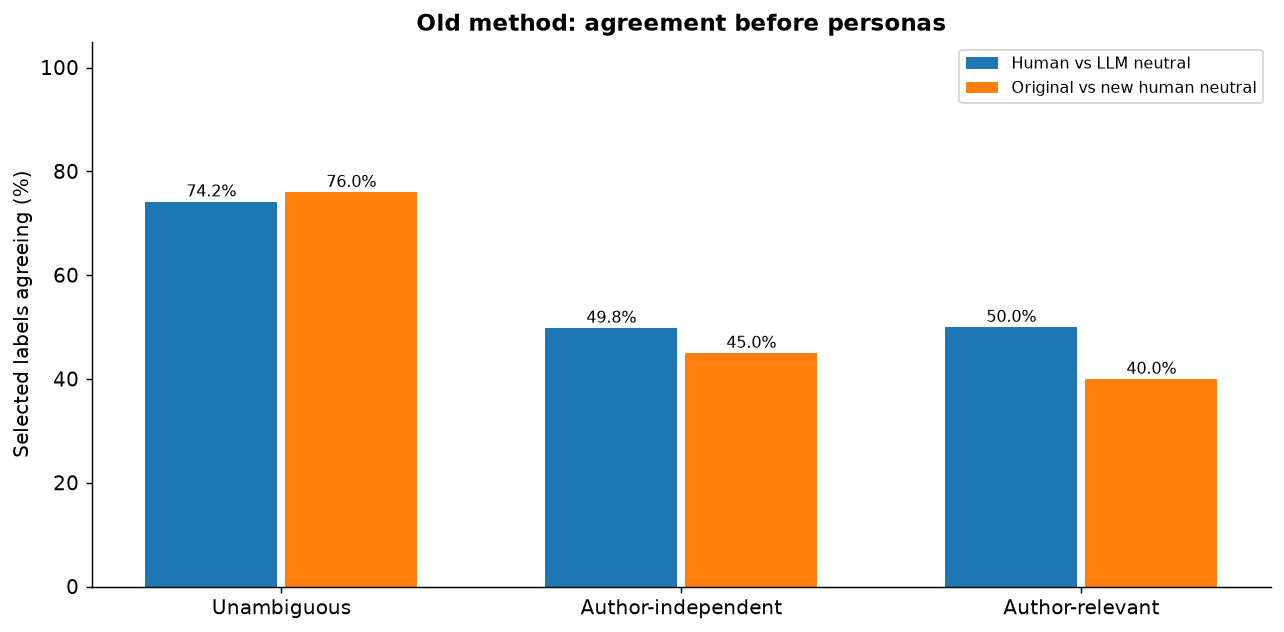

,comparison,category,comparisons,agreement_pct
0,Human vs LLM neutral,author_independent,600,49.8
1,Human vs LLM neutral,author_relevant,600,50.0
2,Human vs LLM neutral,unambiguous,600,74.2
3,Original vs new human neutral,author_independent,100,45.0
4,Original vs new human neutral,author_relevant,100,40.0
5,Original vs new human neutral,unambiguous,100,76.0


**What it means:** even with no author at all, two groups of readers pick the same winning emotion only about half the time on ambiguous texts. Any persona effect has to beat this background disagreement. A match or mismatch also hides *how* different the votes are.

In [9]:
baseline_rows = baseline(study)
base_label = baseline_rows.groupby(['comparison', 'category']).agg(
    comparisons=('text_id', 'size'), agreement_pct=('label_agrees', lambda x: 100 * x.mean())).reset_index()
fig, ax = plt.subplots(figsize=(10, 5))
for j, comp in enumerate(base_label.comparison.unique()):
    sub = base_label[base_label.comparison == comp].set_index('category').reindex(CATS)
    ax.bar(np.arange(3) + (j - .5) * .35, sub.agreement_pct, .33, label=comp)
    for i, v in enumerate(sub.agreement_pct):
        ax.text(i + (j - .5) * .35, v + 1, f'{v:.1f}%', ha='center', fontsize=9)
ax.set_xticks(range(3), CAT_NAMES)
ax.set_ylim(0, 105)
ax.set_ylabel('Selected labels agreeing (%)')
ax.set_title('Old method: agreement before personas')
ax.legend(fontsize=9)
finish(fig, 'old_baseline_agreement')
table(base_label, 'old_baseline_agreement', 1)
explain('**What it means:** even with no author at all, two groups of readers pick the same winning '
        'emotion only about half the time on ambiguous texts. Any persona effect has to beat this '
        'background disagreement. A match or mismatch also hides *how* different the votes are.')

## A3. Under a persona, how often does the winning emotion change?

For each comparison: 1 if the winning emotion changed, 0 if not. The bars show the percentage
that changed.

**How the averages and error bars work** (`summary`, `boot_mean`): each text first gets its own
average (humans have 2 comparisons per text, models 12), so every text counts once. The black
error bar is the **95% range**: redraw the 100 texts with replacement 10,000 times, recompute the
average each time, and keep the middle 95%.

In [10]:
def boot_mean(x, seed=42, n=N_RANDOM):
    """Mean plus a 95% error bar. The error bar: redraw the list of values (one per TEXT) with
    replacement 10,000 times, recompute the mean each time, keep the middle 95%."""
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if not len(x):
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    means = x[rng.integers(0, len(x), (n, len(x)))].mean(axis=1)
    return float(x.mean()), *np.quantile(means, [.025, .975])


def summary(study, metric, by_category=True):
    """Average of a measure, first per text (so each text counts once), then over texts."""
    groups = ['source'] + (['category'] if by_category else [])
    rows = []
    for key, g in study.cells.groupby(groups, sort=False):
        key = key if isinstance(key, tuple) else (key,)
        per_text = g.groupby('text_id')[metric].mean().to_numpy(float)
        mean, lo, hi = boot_mean(per_text)
        rows.append(dict(zip(groups, key)) | dict(comparisons=len(g), texts=len(per_text),
                                                  value_pct=100 * mean, lo_pct=100 * lo, hi_pct=100 * hi))
    return pd.DataFrame(rows)


def bar(study, metric, name, title, ylabel):
    """Bar chart of summary() by group, humans next to models, with 95% error bars."""
    d = summary(study, metric)
    fig, ax = plt.subplots(figsize=(10, 5))
    for j, src in enumerate(['Human', 'LLM']):
        q = d[d.source == src].set_index('category').reindex(CATS)
        x = np.arange(3) + (j - .5) * .35
        ax.bar(x, q.value_pct, .33, label=src, color=COLORS[src])
        ax.errorbar(x, q.value_pct, yerr=[q.value_pct - q.lo_pct, q.hi_pct - q.value_pct],
                    fmt='none', color='#303030', capsize=4)
        for xx, yy in zip(x, q.value_pct):
            ax.text(xx, yy + 1.5, f'{yy:.1f}%', ha='center', fontsize=10)
    ax.set_xticks(range(3), CAT_NAMES)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.set_ylim(0, min(110, max(d.hi_pct) * 1.22 + 3))
    finish(fig, name)
    table(d, name)
    return d

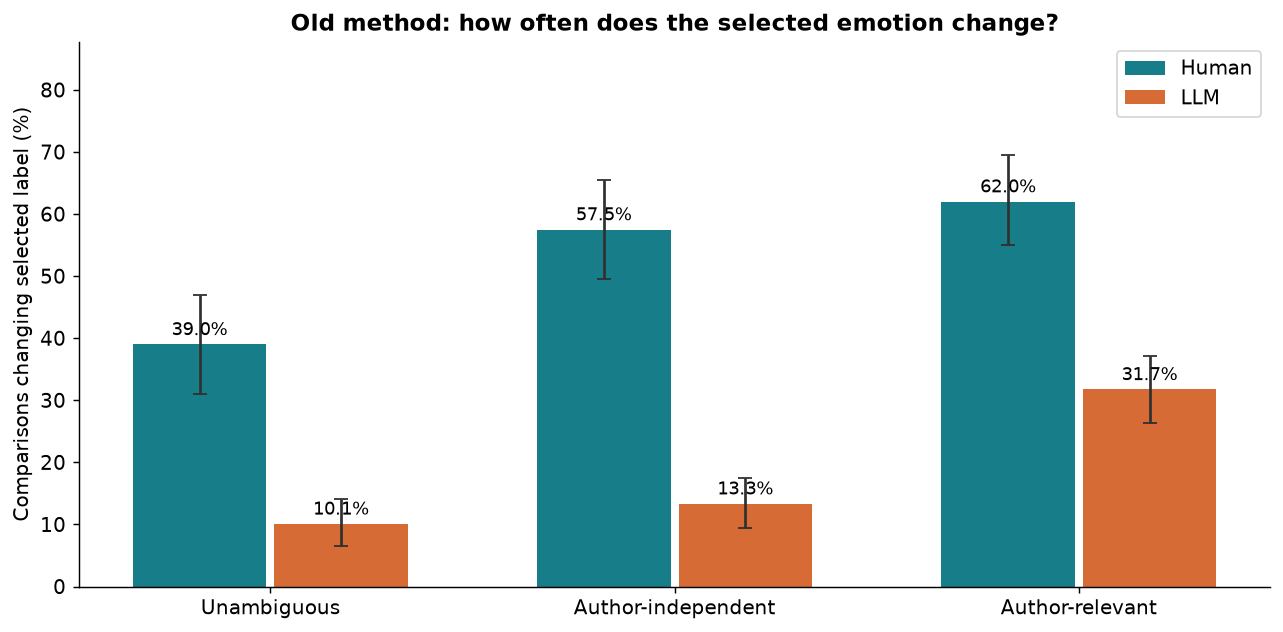

,source,category,comparisons,texts,value_pct,lo_pct,hi_pct
0,Human,author_relevant,200,100,62.000,55.000,69.500
1,Human,author_independent,200,100,57.500,49.500,65.500
2,Human,unambiguous,200,100,39.000,31.000,47.000
3,LLM,author_relevant,1200,100,31.750,26.417,37.167
4,LLM,author_independent,1200,100,13.333,9.500,17.417
5,LLM,unambiguous,1200,100,10.083,6.500,14.083


,source,comparisons,texts,value_pct,lo_pct,hi_pct
0,Human,600,300,52.83,48.33,57.50
1,LLM,3600,300,18.39,15.64,21.25


**Human:** the winning emotion changes in 52.8% of comparisons. Every other comparison counts as "unchanged", whatever happened to the other votes.

**LLM:** the winning emotion changes in 18.4% of comparisons. Every other comparison counts as "unchanged", whatever happened to the other votes.

**Not yet evidence:** people change 39% of the time even on clear texts, partly just because different people rated each version. Whether this beats chance is tested in A5.

In [11]:
old_rates = bar(study, 'flip', 'old_label_change_rates', 'Old method: how often does the selected emotion change?',
                'Comparisons changing selected label (%)')
old_total = summary(study, 'flip', False)
table(old_total, 'old_overall_change_rates', 2)
for _, r in old_total.iterrows():
    explain(f'**{r.source}:** the winning emotion changes in {r.value_pct:.1f}% of comparisons. '
            'Every other comparison counts as "unchanged", whatever happened to the other votes.')
explain('**Not yet evidence:** people change 39% of the time even on clear texts, partly just because '
        'different people rated each version. Whether this beats chance is tested in A5.')

## A4. Which emotion turns into which?

Rows = winning emotion without a persona, columns = with a persona. The diagonal means no change.

In [12]:
def transitions(study):
    """Count how often each winning neutral emotion (rows) becomes each persona emotion (columns)."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 6))
    for ax, (src, d) in zip(axes, [('Human', study.h), ('LLM', study.l)]):
        mat = pd.crosstab(d.winner0, d.winner1).reindex(index=range(11), columns=range(11), fill_value=0)
        arr = mat.to_numpy()
        ax.imshow(arr, cmap='Blues')
        for i in range(11):
            for j in range(11):
                if arr[i, j]:
                    ax.text(j, i, str(arr[i, j]), ha='center', va='center', fontsize=7,
                            color='white' if arr[i, j] > arr.max() / 2 else 'black')
        ax.set_xticks(range(11), E, rotation=60, ha='right', fontsize=8)
        ax.set_yticks(range(11), E, fontsize=8)
        ax.set_title(f'{src}: {len(d):,} comparisons')
        ax.set_xlabel('Selected persona label')
        ax.set_ylabel('Selected neutral label')
    finish(fig, 'old_transitions')

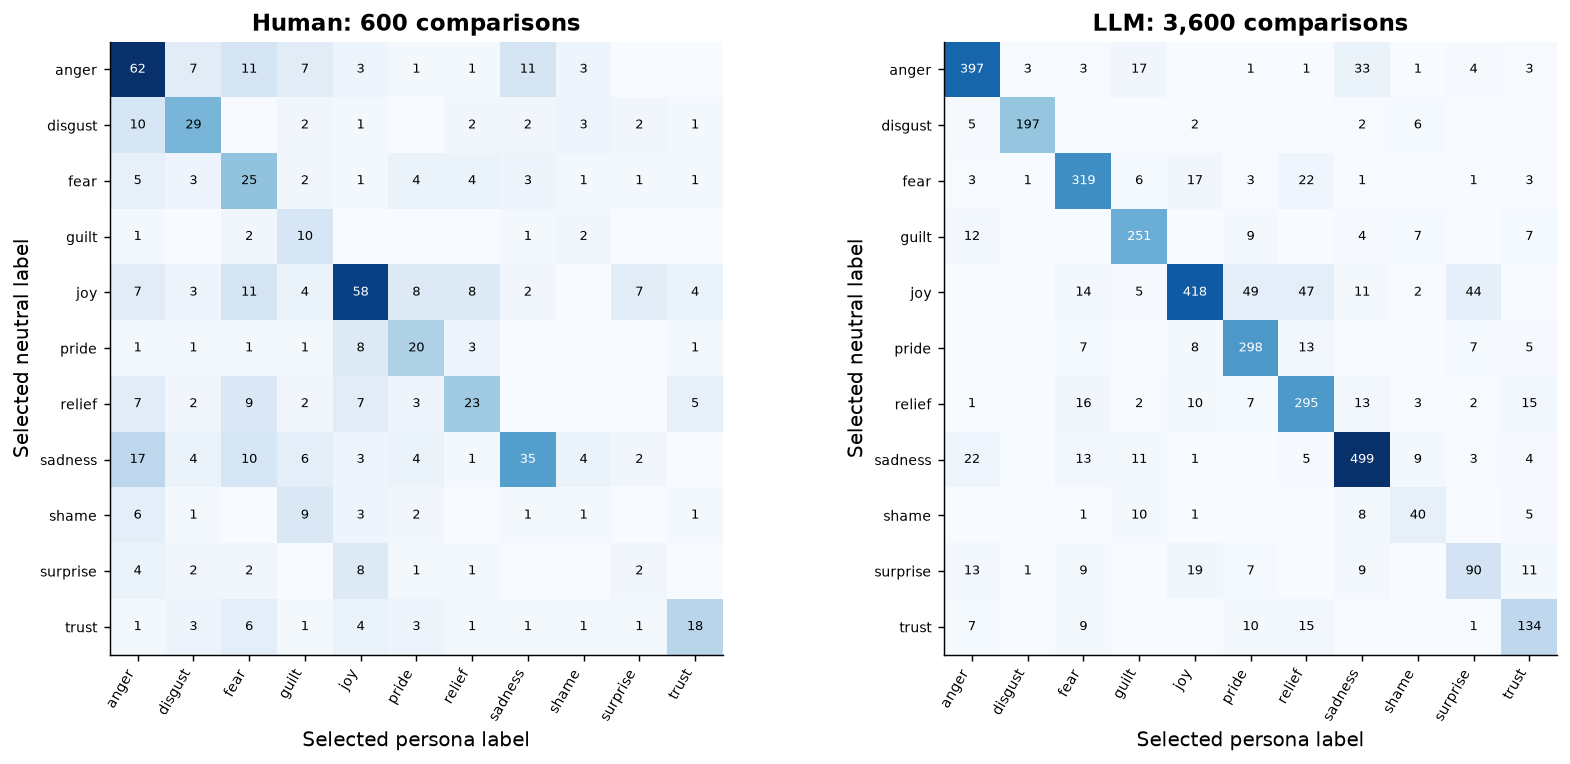

**What it adds:** now we can see *which* switches happen (models mostly move from joy to pride, relief or surprise). **Still missing:** how much of the vote moved, and any change that does not flip the winner.

In [13]:
transitions(study)
explain('**What it adds:** now we can see *which* switches happen (models mostly move from joy to pride, '
        'relief or surprise). **Still missing:** how much of the vote moved, and any change that does '
        'not flip the winner.')

## A5. H1 and H2, the old way: are these changes more than chance?

**The idea: a chance shuffle** (`chance_shuffles`). If the persona did nothing, it would not matter
which votes came from which version.
- **Humans:** different people rated each version, so pool the neutral and persona votes of a text
  and try every way of splitting them back into two groups of the same sizes. With 3 + 3 votes
  there are exactly 20 ways.
- **Models:** the same model answered both versions, so each model's own two answers are either
  kept or swapped. With 7 models that is 128 possibilities.

**The test** (`test_h1_h2`): the observed average is compared with 10,000 averages built from these
chance possibilities. **p** = the share of chance averages at least as big as the observed one.

**Holm correction** (`holm_correct`): H1 is 6 tests (3 groups × 2 personas). Running 6 tests raises
the odds of a lucky pass, so the p-values are adjusted upwards before comparing with 0.05.

In the graph, the dot is the observed value, the × is what chance gives on average, and the
label is the corrected p-value.

In [14]:
def chance_shuffles(study, source, index):
    """For ONE comparison, list every way the votes could have come out if the persona did nothing.
    Humans (different people per version): pool the neutral and persona votes, then try every way
      of splitting them back into two groups of the original sizes (3 + 3 votes = 20 ways).
    Models (the same model answered both versions): each model's own two answers are either kept
      or swapped, giving 2 x 2 x ... possibilities (128 for 7 models).
    Returns, for every possibility, whether the label changed and how big the shift is."""
    key = (source, index)
    if key in study.null_cache:
        return study.null_cache[key]
    r = (study.h if source == 'Human' else study.l).iloc[index]
    a, b = r.neutral_votes, r.persona_votes
    if source == 'Human':
        pool = np.concatenate([a, b])
        n = len(a)
        total = np.bincount(pool, minlength=len(E))
        counts = np.array([np.bincount(pool[list(c)], minlength=len(E))
                           for c in combinations(range(len(pool)), n)])
        pa = counts / n
        pb = (total - counts) / len(b)
    else:
        swaps = np.array(list(product([False, True], repeat=len(a))))
        av = np.where(swaps, b, a)
        bv = np.where(swaps, a, b)
        pa = np.eye(len(E))[av].mean(axis=1)
        pb = np.eye(len(E))[bv].mean(axis=1)
    result = {'flip': (pa.argmax(axis=1) != pb.argmax(axis=1)).astype(float),
              'tv': np.abs(pa - pb).sum(axis=1) / 2}
    study.null_cache[key] = result
    return result


def holm_correct(pvals):
    """Holm correction: sort the p-values, multiply the smallest by the number of tests, the next
    by one less, and so on; never let an adjusted value drop below the one before it; cap at 1."""
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    adj = np.empty(n)
    running_max = 0.0
    for rank, idx in enumerate(order):
        val = min((n - rank) * pvals[idx], 1.0)
        running_max = max(running_max, val)
        adj[idx] = running_max
    return adj


def test_h1_h2(study, metric):
    """H1 (humans: 3 groups x 2 personas = 6 tests) and H2 (models: 2 personas = 2 tests).
    metric is 'flip' (old method: did the label change?) or 'tv' (vector method: shift size).
    For each test:
      1. observed = average of the metric over the comparisons in that group;
      2. chance = 10,000 times, give every comparison one random outcome from chance_shuffles()
         and average them -> 10,000 averages that could happen if the persona did nothing;
      3. p = share of those chance averages that are at least as big as the observed one."""
    if metric in study.test_cache:
        return study.test_cache[metric].copy()
    rows = []
    for source, d in [('Human', study.h), ('LLM', study.l)]:
        for side in ['a', 'b']:
            for cat in (CATS if source == 'Human' else ['all']):
                sub = d[(d.side == side) & ((d.category == cat) if cat != 'all' else True)]
                rng = np.random.default_rng(4200 + len(rows))
                null = np.zeros(N_RANDOM)
                expect = 0
                for index in sub.index:
                    values = chance_shuffles(study, source, index)[metric]
                    null += values[rng.integers(0, len(values), N_RANDOM)]
                    expect += values.mean()
                null /= len(sub)
                expect /= len(sub)
                obs = sub[metric].mean()
                p = (1 + np.count_nonzero(null >= obs - 1e-12)) / (N_RANDOM + 1)
                mean, lo, hi = boot_mean(sub.groupby('text_id')[metric].mean())
                rows.append(dict(hypothesis='H1' if source == 'Human' else 'H2', source=source,
                                 side=side, category=cat, n_cells=len(sub), observed_pct=100 * obs,
                                 conditional_null_pct=100 * expect, excess_pp=100 * (obs - expect),
                                 ci_lo=100 * lo, ci_hi=100 * hi, p_raw=p))
    out = pd.DataFrame(rows)
    out['p_holm'] = np.nan
    for h in ['H1', 'H2']:                 # correct H1's 6 tests together, H2's 2 tests together
        use = out.hypothesis == h
        out.loc[use, 'p_holm'] = holm_correct(out.loc[use, 'p_raw'])
    out['reject_05'] = out.p_holm < .05
    study.test_cache[metric] = out
    return out.copy()


def plot_h1_h2(study, metric, name):
    """Dot = observed value with 95% error bar; x = what chance alone gives; label = Holm p."""
    d = test_h1_h2(study, metric)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={'width_ratios': [2, 1]})
    for ax, h in zip(axes, ['H1', 'H2']):
        q = d[d.hypothesis == h].reset_index(drop=True)
        y = np.arange(len(q))
        ax.errorbar(q.observed_pct, y, xerr=[q.observed_pct - q.ci_lo, q.ci_hi - q.observed_pct],
                    fmt='o', color='#177e89', capsize=3, label='Observed; 95% text CI')
        ax.scatter(q.conditional_null_pct, y, marker='x', color='#d66b35', label='Conditional-null mean')
        ax.set_yticks(y, [('All texts' if r.category == 'all' else CAT_NAME[r.category]) + ' / '
                          + r.side.upper() for _, r in q.iterrows()])
        for i, r in q.iterrows():
            ax.annotate(f'p={r.p_holm:.4f}', (r.observed_pct, i), xytext=(0, 10),
                        textcoords='offset points', fontsize=8)
        ax.set_xlim(0, 100)
        ax.set_title(h + ': ' + ('one-label changes' if metric == 'flip' else 'distribution distances'))
        ax.set_xlabel('Changed comparisons (%)' if metric == 'flip' else 'TV × 100')
        ax.set_ylim(-.7, len(q) - .3)
    axes[0].legend(fontsize=8, loc='lower left')
    finish(fig, name)
    table(d, name)
    return d

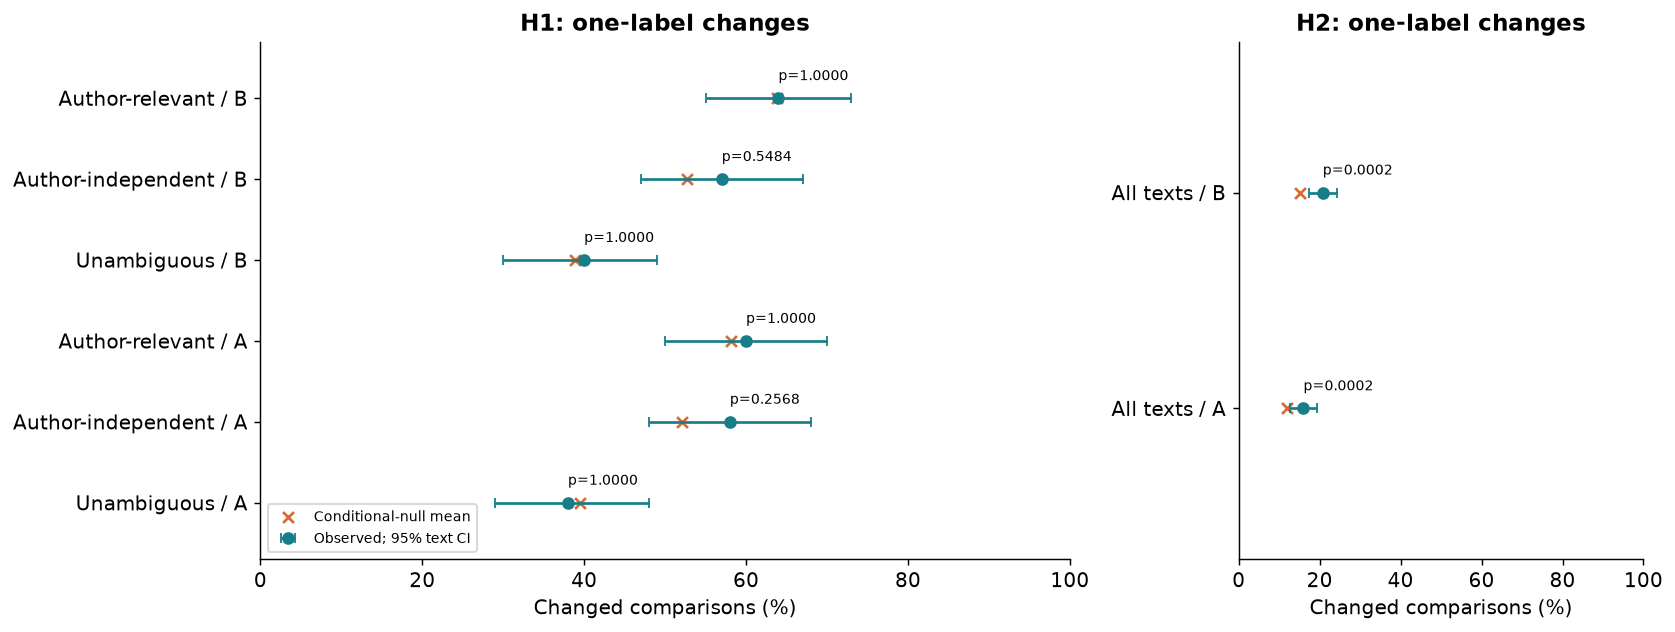

,hypothesis,source,side,category,n_cells,observed_pct,conditional_null_pct,excess_pp,ci_lo,ci_hi,p_raw,p_holm,reject_05
0,H1,Human,a,unambiguous,100,38.000,39.479,-1.479,29.000,48.000,0.7662,1,False
1,H1,Human,a,author_independent,100,58.000,52.026,5.974,48.000,68.000,0.0428,0.2568,False
2,H1,Human,a,author_relevant,100,60.000,58.164,1.836,50.000,70.000,0.346,1,False
3,H1,Human,b,unambiguous,100,40.000,38.904,1.096,30.000,49.000,0.4158,1,False
4,H1,Human,b,author_independent,100,57.000,52.739,4.261,47.000,67.000,0.1097,0.5484,False
5,H1,Human,b,author_relevant,100,64.000,63.789,0.211,55.000,73.000,0.5353,1,False
6,H2,LLM,a,all,1800,16.000,11.812,4.188,12.778,19.279,9.999e-05,0.0002,True
7,H2,LLM,b,all,1800,20.778,15.235,5.543,17.389,24.333,9.999e-05,0.0002,True


**H1, old method:** 0 of 6 tests are significant after correction.

**H2, old method:** 2 of 2 tests are significant after correction.

**What it means:** counting only the winning emotion, **no human framing effect is detected**. The model effect is detected. "Not detected" is not the same as "no effect": Part C tests the same question with all the votes.

In [15]:
old_h12 = plot_h1_h2(study, 'flip', 'old_H1_H2')
for hyp in ['H1', 'H2']:
    q = old_h12[old_h12.hypothesis == hyp]
    explain(f'**{hyp}, old method:** {q.reject_05.sum()} of {len(q)} tests are significant after correction.')
explain('**What it means:** counting only the winning emotion, **no human framing effect is detected**. '
        'The model effect is detected. "Not detected" is not the same as "no effect": Part C tests '
        'the same question with all the votes.')

## A6. H3, the old way: do author-relevant texts change more?

H3 is specifically **author-relevant minus author-independent**. Each text gets one number (its
average over the two personas); the groups are compared, and the p-value comes from shuffling
which group each text belongs to (`test_h3`).

In [16]:
def test_h3(study, metric):
    """H3: do author-relevant texts change more than author-independent ones (humans)?
    Each text gets one number = its average over the two personas.
    'Raw' compares those numbers directly.
    'Conditional-null referenced' first subtracts what chance alone would give for that same
      text (the average of chance_shuffles), then compares what is left (the 'excess').
    p-value: shuffle which group each text belongs to 10,000 times and see how often the
      difference between the group averages is at least as big as the real one (either sign).
    Error bar: resample the texts within each group 10,000 times."""
    d = study.h.copy()
    d['expected'] = [chance_shuffles(study, 'Human', i)[metric].mean() for i in d.index]
    d['excess'] = d[metric] - d.expected
    t = d.groupby(['text_id', 'category'])[[metric, 'expected', 'excess']].mean().reset_index()
    rows = []
    for mode, col in [('Raw', metric), ('Conditional-null referenced', 'excess')]:
        for a, b in [('author_relevant', 'author_independent'), ('author_independent', 'unambiguous'),
                     ('author_relevant', 'unambiguous')]:
            x = t.loc[t.category == a, col].to_numpy()
            y = t.loc[t.category == b, col].to_numpy()
            obs = x.mean() - y.mean()
            rng = np.random.default_rng(102 + len(rows))
            pooled = np.r_[x, y]
            indices = np.argsort(rng.random((N_RANDOM, len(pooled))), axis=1)
            perms = pooled[indices]
            null = perms[:, :len(x)].mean(axis=1) - perms[:, len(x):].mean(axis=1)
            p = (1 + (np.abs(null) >= abs(obs) - 1e-12).sum()) / (N_RANDOM + 1)
            boots = (x[rng.integers(0, len(x), (N_RANDOM, len(x)))].mean(axis=1)
                     - y[rng.integers(0, len(y), (N_RANDOM, len(y)))].mean(axis=1))
            lo, hi = np.quantile(boots, [.025, .975])
            rows.append(dict(analysis=mode, contrast=CAT_NAME[a] + ' minus ' + CAT_NAME[b],
                             difference_pp=100 * obs, ci_lo=100 * lo, ci_hi=100 * hi, p_raw=p))
    out = pd.DataFrame(rows)
    out['p_holm'] = np.nan
    for mode in out.analysis.unique():     # Holm over the 3 contrasts, separately per analysis
        use = out.analysis == mode
        out.loc[use, 'p_holm'] = holm_correct(out.loc[use, 'p_raw'])
    return out, t

,analysis,contrast,difference_pp,ci_lo,ci_hi,p_raw,p_holm
0,Raw,Author-relevant minus Author-independent,4.5,-6.0,15.0,0.4721,0.4721
1,Raw,Author-independent minus Unambiguous,18.5,7.0,29.5,0.002,0.004
2,Raw,Author-relevant minus Unambiguous,23.0,12.0,34.0,9.999e-05,0.0003


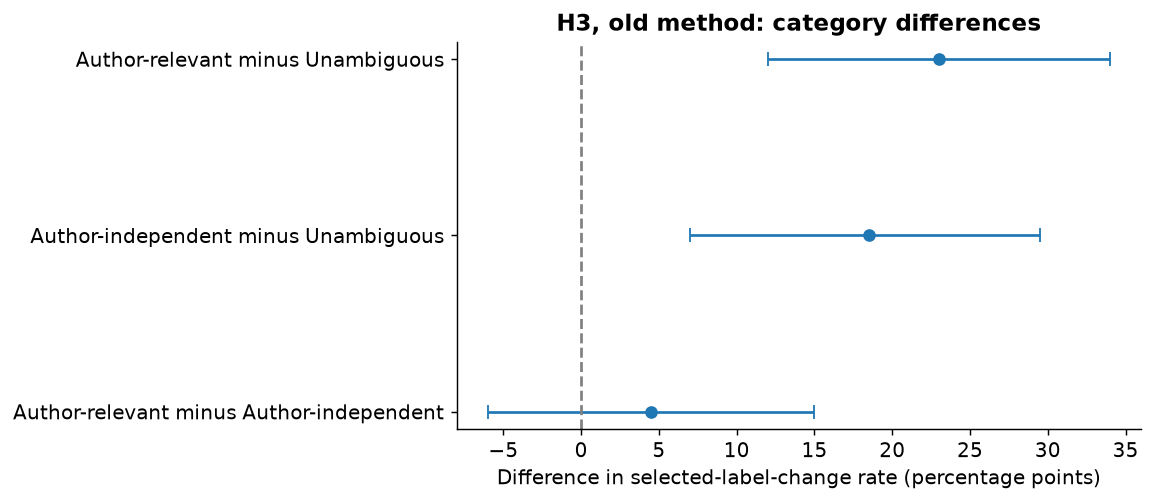

**H3, old method:** author-relevant texts change their label 4.50 points more often than author-independent ones; 95% range [-6.00, 15.00], corrected p = 0.4721. The range includes zero, so no difference is detected.

In [17]:
old_h3, old_h3_text = test_h3(study, 'flip')
old_h3_raw = old_h3[old_h3.analysis == 'Raw']
table(old_h3_raw, 'old_H3_raw')
r = old_h3_raw.iloc[0]
fig, ax = plt.subplots(figsize=(9, 4))
ax.errorbar(old_h3_raw.difference_pp, np.arange(3),
            xerr=[old_h3_raw.difference_pp - old_h3_raw.ci_lo, old_h3_raw.ci_hi - old_h3_raw.difference_pp],
            fmt='o', capsize=4)
ax.axvline(0, color='grey', ls='--')
ax.set_yticks(range(3), old_h3_raw.contrast)
ax.set_xlabel('Difference in selected-label-change rate (percentage points)')
ax.set_title('H3, old method: category differences')
finish(fig, 'old_H3_contrasts')
explain(f'**H3, old method:** author-relevant texts change their label {r.difference_pp:.2f} points more often '
        f'than author-independent ones; 95% range [{r.ci_lo:.2f}, {r.ci_hi:.2f}], corrected p = {r.p_holm:.4f}. '
        + ('That is significant.' if r.p_holm < .05 else
           'The range includes zero, so no difference is detected.'))

## A7. H4, the old way: what can one label say?

Two rough stand-ins, because one label cannot measure the size or direction of a full shift:
1. **Size stand-in:** do people change their label more often than models?
2. **Direction stand-in:** when *both* change, do they make the *same* switch (e.g. both sadness →
   guilt)? Chance: pair each text's human results with a random other text's model results.

In [18]:
def h4_size(study, metric):
    """Human minus model, per text (each text's average over its comparisons), then averaged."""
    h = study.h.groupby('text_id')[metric].mean().reindex(study.ids)
    l = study.l.groupby('text_id')[metric].mean().reindex(study.ids)
    point, lo, hi = boot_mean(h - l)
    return pd.DataFrame([dict(metric=metric, n_texts=300, human_mean_pct=100 * h.mean(),
                              llm_mean_pct=100 * l.mean(), human_minus_llm_pp=100 * point,
                              ci_lo=100 * lo, ci_hi=100 * hi)])


def label_agreement(study):
    """Match every model comparison with the human comparison for the same text and persona,
    and record who changed their selected label."""
    h = study.h[['text_id', 'side', 'flip', 'winner0', 'winner1']].rename(
        columns={c: 'h_' + c for c in ['flip', 'winner0', 'winner1']})
    j = study.l.merge(h, on=['text_id', 'side'], validate='many_to_one')
    j['status'] = np.select([(j.h_flip == 0) & (j.flip == 0), (j.h_flip == 1) & (j.flip == 0),
                             (j.h_flip == 0) & (j.flip == 1)],
                            ['Both keep their label', 'Only humans change label', 'Only LLMs change label'],
                            default='Both change label')
    both = (j.h_flip == 1) & (j.flip == 1)
    agree = (j.winner0 == j.h_winner0) & (j.winner1 == j.h_winner1)
    return j, pd.DataFrame([dict(comparisons=len(j), both_changed=int(both.sum()),
                                 same_transition_among_both_changed=int((both & agree).sum()),
                                 same_transition_pct=100 * agree[both].mean(),
                                 change_status_agreement_pct=100 * (j.h_flip == j.flip).mean())])


def label_direction(study):
    """Old-method stand-in for direction: when BOTH humans and models change their label, how often
    is it the same switch (same start AND end emotion)? Chance: pair each text's human results
    with another random text's model results, 10,000 times."""
    j, _ = label_agreement(study)
    j = j.sort_values(['text_id', 'side', 'config'], key=lambda x: x.astype(int) if x.name == 'text_id' else x)
    h0 = j.h_winner0.to_numpy().reshape(300, 12)
    h1 = j.h_winner1.to_numpy().reshape(300, 12)
    l0 = j.winner0.to_numpy().reshape(300, 12)
    l1 = j.winner1.to_numpy().reshape(300, 12)
    eligible = (h0 != h1) & (l0 != l1)
    same = (h0 == l0) & (h1 == l1) & eligible
    sums = same.sum(axis=1)
    counts = eligible.sum(axis=1)
    obs = sums.sum() / counts.sum()
    rng = np.random.default_rng(302)
    idx = rng.integers(0, 300, (N_RANDOM, 300))
    boots = sums[idx].sum(axis=1) / counts[idx].sum(axis=1)
    lo, hi = np.quantile(boots, [.025, .975])
    null = np.empty(N_RANDOM)
    for b in range(N_RANDOM):
        ix = rng.permutation(300)
        ok = (h0 != h1) & (l0[ix] != l1[ix])
        match = (h0 == l0[ix]) & (h1 == l1[ix]) & ok
        null[b] = match.sum() / ok.sum() if ok.any() else np.nan
    p = (1 + np.count_nonzero(null >= obs - 1e-12)) / (1 + np.isfinite(null).sum())
    return pd.DataFrame([dict(eligible_comparisons=int(counts.sum()), same_selected_transition=int(sums.sum()),
                              agreement_pct=100 * obs, ci_lo=100 * lo, ci_hi=100 * hi,
                              null_mean_pct=100 * np.nanmean(null), p_permutation=p)])

,metric,n_texts,human_mean_pct,llm_mean_pct,human_minus_llm_pp,ci_lo,ci_hi
0,flip,300,52.833,18.389,34.444,29.639,39.306


,comparisons,both_changed,same_transition_among_both_changed,same_transition_pct,change_status_agreement_pct
0,3600,438,102,23.288,53.111


,eligible_comparisons,same_selected_transition,agreement_pct,ci_lo,ci_hi,null_mean_pct,p_permutation
0,438,102,23.288,15.691,31.776,1.786,9.999e-05


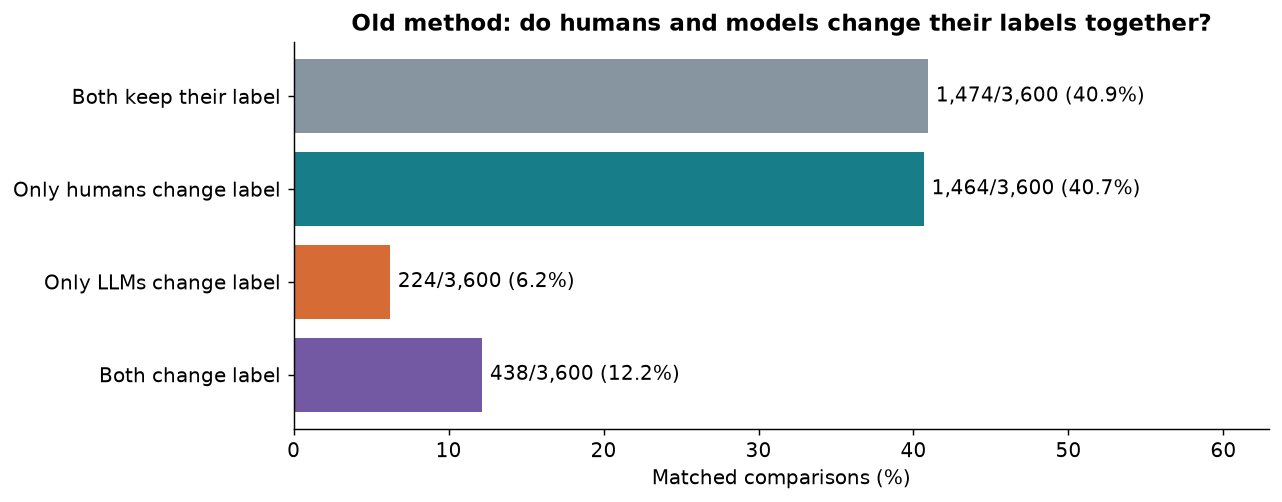

**Size stand-in:** people change their label 34.44 points more often than models (range [29.64, 39.31]). **Direction stand-in:** in 23.3% of the 438 cases where both changed, they made the same switch; chance gives 1.8% (p = 0.0001).

In [19]:
old_h4 = h4_size(study, 'flip')
table(old_h4, 'old_H4_frequency')
old_pairs, old_agreement = label_agreement(study)
table(old_agreement, 'old_H4_change_agreement')
old_direction = label_direction(study)
table(old_direction, 'old_H4_transition_proxy')
status = old_pairs.status.value_counts().reindex(
    ['Both keep their label', 'Only humans change label', 'Only LLMs change label', 'Both change label'],
    fill_value=0)
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(status.index, status.values / len(old_pairs) * 100, color=['#8795a1', '#177e89', '#d66b35', '#7359a3'])
ax.invert_yaxis()
for i, n in enumerate(status):
    ax.text(n / len(old_pairs) * 100 + .5, i, f'{n:,}/3,600 ({n / len(old_pairs) * 100:.1f}%)', va='center')
ax.set_xlim(0, max(status) / len(old_pairs) * 100 + 22)
ax.set_xlabel('Matched comparisons (%)')
ax.set_title('Old method: do humans and models change their labels together?')
finish(fig, 'old_H4_status')
r = old_h4.iloc[0]
dr = old_direction.iloc[0]
explain(f'**Size stand-in:** people change their label {r.human_minus_llm_pp:.2f} points more often than models '
        f'(range [{r.ci_lo:.2f}, {r.ci_hi:.2f}]). **Direction stand-in:** in {dr.agreement_pct:.1f}% of the '
        f'{int(dr.eligible_comparisons):,} cases where both changed, they made the same switch; chance gives '
        f'{dr.null_mean_pct:.1f}% (p = {dr.p_permutation:.4f}).')

## A8. Summary of the old method

In [20]:
n_h1_old = int(old_h12.query("hypothesis == 'H1'").reject_05.sum())
n_h2_old = int(old_h12.query("hypothesis == 'H2'").reject_05.sum())
old_summary = pd.DataFrame([
    {'hypothesis': 'H1', 'old_method_answer': f'{n_h1_old}/6 adjusted tests reject; category/side-specific',
     'scope': 'Selected-label-change rate; non-rejection is not absence'},
    {'hypothesis': 'H2', 'old_method_answer': f'{n_h2_old}/2 adjusted tests reject',
     'scope': 'Ensemble selected-label changes, preserving model pairs'},
    {'hypothesis': 'H3', 'old_method_answer': f'AR−AI {old_h3_raw.iloc[0].difference_pp:.2f}pp; adjusted p={old_h3_raw.iloc[0].p_holm:.4f}',
     'scope': 'Raw category difference in label-change frequency'},
    {'hypothesis': 'H4', 'old_method_answer': f'Human−model label-change frequency {old_h4.iloc[0].human_minus_llm_pp:.2f}pp; transition agreement {old_direction.iloc[0].agreement_pct:.1f}%',
     'scope': 'Only categorical proxies; full magnitude/direction unavailable'}])
table(old_summary, 'old_hypothesis_summary')

,hypothesis,old_method_answer,scope
0,H1,0/6 adjusted tests reject; category/side-specific,Selected-label-change rate; non-rejection is n...
1,H2,2/2 adjusted tests reject,"Ensemble selected-label changes, preserving mo..."
2,H3,AR−AI 4.50pp; adjusted p=0.4721,Raw category difference in label-change frequency
3,H4,Human−model label-change frequency 34.44pp; tr...,Only categorical proxies; full magnitude/direc...


# Part B: What does the old method throw away?

## B1. Ties make the answer depend on an arbitrary rule

Repeat the label-change count with ties broken by the **reverse** alphabet. If the result
changes, the old method depends on a rule that has nothing to do with the data.

In [21]:
def ties(study):
    """How much does the arbitrary tie rule matter? Compare alphabetical vs reverse-alphabetical."""
    rows = []
    for src, g in study.cells.groupby('source', sort=False):
        unique = ~g.neutral_tie & ~g.persona_tie
        rows.append(dict(source=src, comparisons=len(g), either_condition_tied=int((~unique).sum()),
                         alphabetic_change_pct=100 * g.flip.mean(),
                         reverse_order_change_pct=100 * g.flip_reverse.mean(),
                         changed_decision=int((g.flip != g.flip_reverse).sum()),
                         unique_winners_only_n=int(unique.sum()),
                         unique_winners_only_change_pct=100 * g.loc[unique, 'flip'].mean()))
    return pd.DataFrame(rows)

In [22]:
tie_report = ties(study)
table(tie_report, 'tie_rule_sensitivity', 2)
explain('**What it means:** `changed_decision` counts comparisons whose changed/unchanged verdict flips just '
        'by reversing the tie rule. For people that is a large share, because 3-vote ties are common.')

,source,comparisons,either_condition_tied,alphabetic_change_pct,reverse_order_change_pct,changed_decision,unique_winners_only_n,unique_winners_only_change_pct
0,Human,600,262,52.83,57.33,125,338,39.05
1,LLM,3600,291,18.39,17.94,212,3309,14.54


**What it means:** `changed_decision` counts comparisons whose changed/unchanged verdict flips just by reversing the tie rule. For people that is a large share, because 3-vote ties are common.

## B2. A label that stays the same can hide real movement

Two ways of counting hidden movement:
- **Same selected label:** the old method says "no change", but the votes moved.
- **Same complete top set:** even keeping all tied winners says "no change", but the votes moved.

Both are shown as a share of **all** comparisons. The table also gives the share of the
"unchanged" comparisons that actually moved (`hidden_pct_of_unchanged_labels`). Do not mix up
the two denominators.

,source,all_comparisons,selected_label_unchanged,moved_with_same_selected_label,hidden_pct_of_all,hidden_pct_of_unchanged_labels,moved_with_same_complete_top_set,same_top_set_hidden_pct
0,Human,600,283,232,38.67,81.98,155,25.83
1,LLM,3600,2938,1492,41.44,50.78,1393,38.69


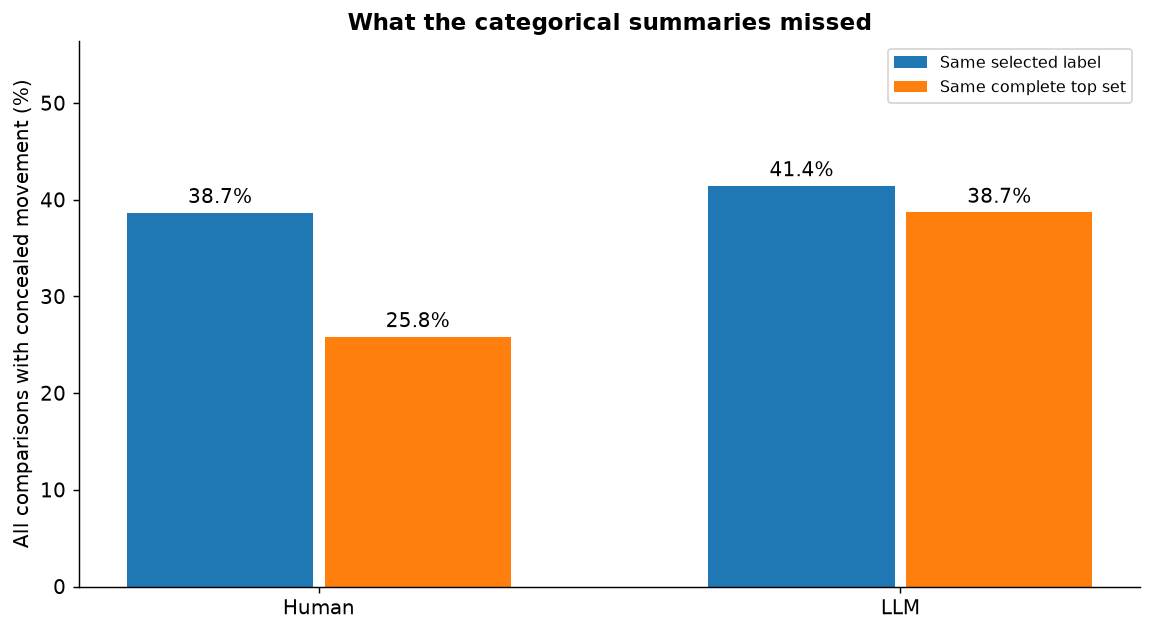

**What it means:** a recorded "unchanged" label does not mean the votes stayed the same. This is lost information; it does not prove every hidden movement is caused by the persona, because small vote samples also vary by chance.

In [23]:
hidden = []
for src, d in [('Human', study.h), ('LLM', study.l)]:
    unchanged = (d.flip == 0).sum()
    hidden.append({'source': src, 'all_comparisons': len(d), 'selected_label_unchanged': int(unchanged),
                   'moved_with_same_selected_label': int(d.hidden_label.sum()),
                   'hidden_pct_of_all': 100 * d.hidden_label.mean(),
                   'hidden_pct_of_unchanged_labels': 100 * d.hidden_label.sum() / unchanged,
                   'moved_with_same_complete_top_set': int(d.hidden_top.sum()),
                   'same_top_set_hidden_pct': 100 * d.hidden_top.mean()})
hidden = pd.DataFrame(hidden)
table(hidden, 'information_lost_by_labels', 2)
fig, ax = plt.subplots(figsize=(9, 5))
for j, col in enumerate(['hidden_pct_of_all', 'same_top_set_hidden_pct']):
    ax.bar(np.arange(2) + (j - .5) * .34, hidden[col], .32, label=['Same selected label', 'Same complete top set'][j])
    for i, v in enumerate(hidden[col]):
        ax.text(i + (j - .5) * .34, v + 1, f'{v:.1f}%', ha='center')
ax.set_xticks(range(2), hidden.source)
ax.set_ylabel('All comparisons with concealed movement (%)')
ax.set_ylim(0, hidden.hidden_pct_of_all.max() + 15)
ax.set_title('What the categorical summaries missed')
ax.legend(fontsize=9)
finish(fig, 'hidden_distribution_movement')
explain('**What it means:** a recorded "unchanged" label does not mean the votes stayed the same. This is '
        'lost information; it does not prove every hidden movement is caused by the persona, because '
        'small vote samples also vary by chance.')

## B3. What exactly is thrown away?

| Lost by keeping one label | Why it matters |
|---|---|
| The vote percentages | A 100% winner and a 34% winner look identical |
| The other emotions | A new minority reading can appear without winning |
| Ties | One label makes a split vote look decisive |
| How far the votes move | A tiny lead change and a complete change both count as one "flip" |
| Direction across all emotions | Several emotions can gain or lose at once |

# Part C: Keep all the votes, then ask the same questions again

From here on, every set of votes is kept as **vote shares** over the 11 emotions (`vec`), and a
change is measured as the **shift** (TV). The texts, people and models are exactly the same as in
Part A; only the way the answers are summarised changes.

## C1. A real example of hidden change

In [24]:
def example(study, event, source, name):
    """Plot the comparison with the LARGEST shift among those that match `event`.
    Chosen because it is the clearest illustration, not because it is typical."""
    d = study.h if source == 'Human' else study.l
    choose = d[d[event]].sort_values(['tv', 'text_id'], ascending=[False, True])
    if choose.empty:
        explain(f'No {source} comparison meets this definition.')
        return
    r = choose.iloc[0]
    p, q = r.p, r.q
    active = np.flatnonzero((p + q) > 0)
    x = np.arange(len(active))
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.bar(x - .18, p[active] * 100, .35, label='Neutral', color='#586f7c')
    ax.bar(x + .18, q[active] * 100, .35, label='Persona', color=COLORS[source])
    for xx, pp, qq in zip(x, p[active] * 100, q[active] * 100):
        ax.text(xx - .18, pp + 1, f'{pp:.0f}%', ha='center', fontsize=9)
        ax.text(xx + .18, qq + 1, f'{qq:.0f}%', ha='center', fontsize=9)
    ax.set_xticks(x, [E[i] for i in active])
    ax.set_ylim(0, 110)
    ax.set_ylabel('Vote share (%)')
    ax.legend()
    ax.set_title(f'{source}, text {r.text_id}, persona {r.side.upper()} — TV {r.tv * 100:.1f}%')
    finish(fig, name)
    explain(f'**Text:** {study.text[r.text_id]}\n\n**Persona:** {study.personas[(r.text_id, r.side)]}\n\n'
            f'**Winning label:** {E[r.winner0]} → {E[r.winner1]}. **Votes:** {r.neutral_n} → {r.persona_n}. '
            f'**Emotions added:** {", ".join(np.array(E)[r.gained]) or "none"}; '
            f'**removed:** {", ".join(np.array(E)[r.lost]) or "none"}. '
            + (f'**Prompt set-up:** {r.config}. ' if source == 'LLM' else '')
            + 'This is the example with the largest shift of its kind, chosen to illustrate, not to be typical.')

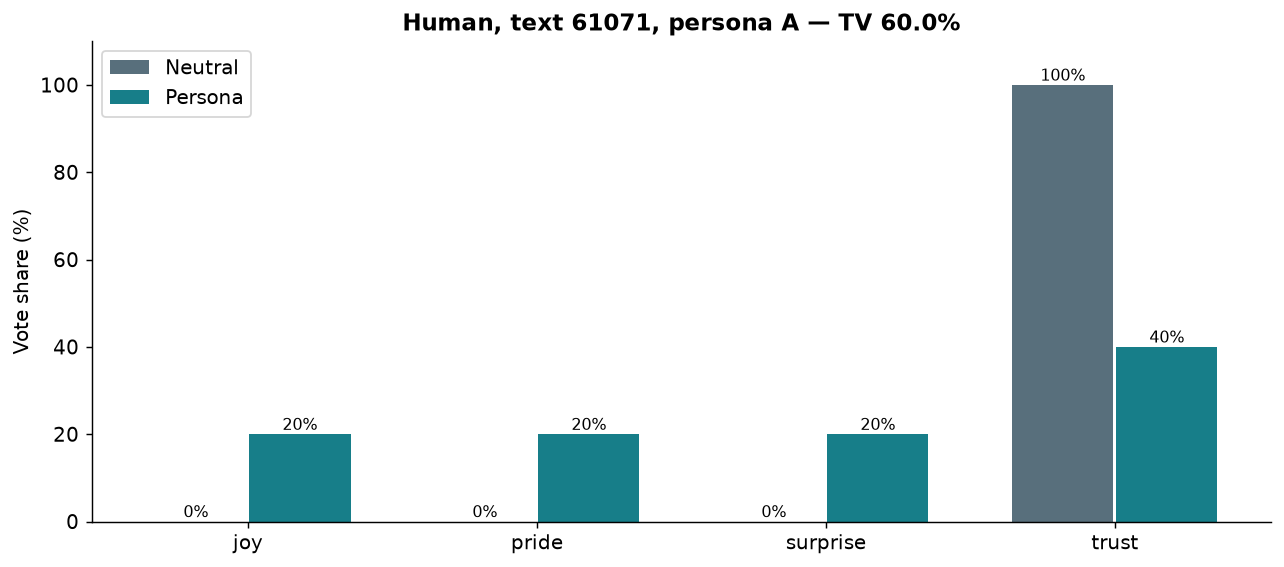

**Text:** My friend needed support to manage her money so she gave me control of her bank accounts

**Persona:** someone entrusted for the first time with this level of financial responsibility

**Winning label:** trust → trust. **Votes:** 3 → 5. **Emotions added:** joy, pride, surprise; **removed:** none. This is the example with the largest shift of its kind, chosen to illustrate, not to be typical.

**Compare with the old method:** the winner is the same on both sides, so the old method records "no change", yet most of the votes moved.

In [25]:
example(study, 'hidden_top', 'Human', 'human_hidden_change_example')
explain('**Compare with the old method:** the winner is the same on both sides, so the old method records '
        '"no change", yet most of the votes moved.')

## C2. Before any persona: how far apart are the vote shares?

The same two comparisons as A2, now measured as a shift instead of match or no match.

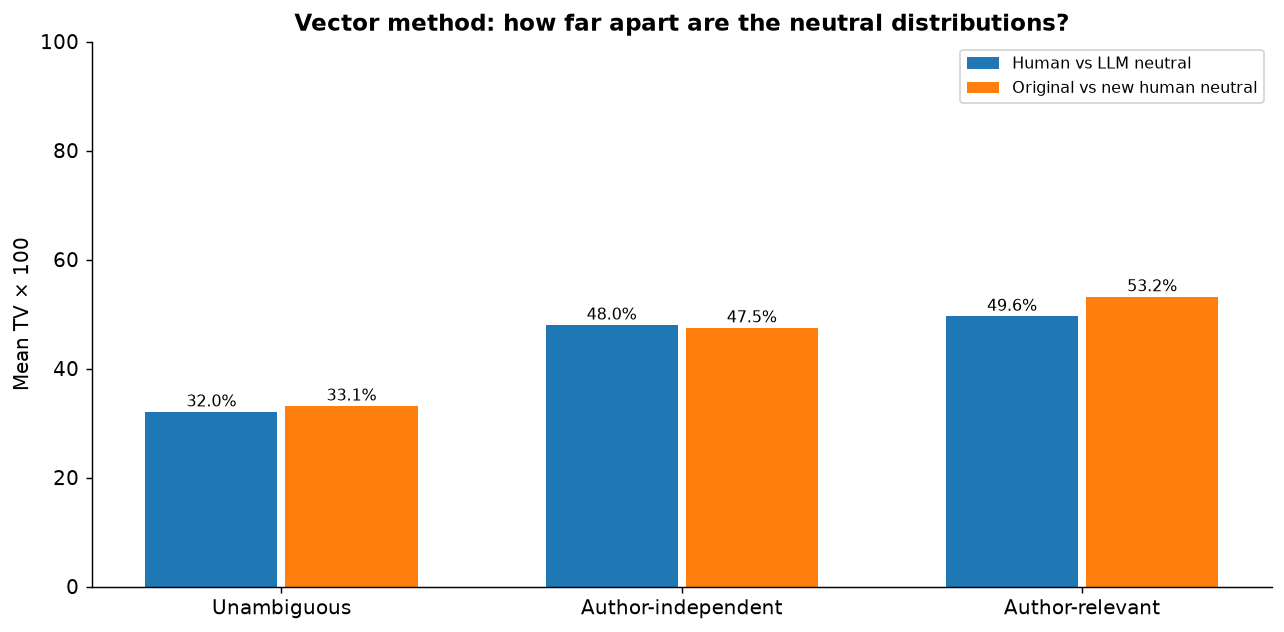

,comparison,category,comparisons,mean_TV_pct,mean_cosine
0,Human vs LLM neutral,author_independent,600,47.99,0.637075
1,Human vs LLM neutral,author_relevant,600,49.60,0.635417
2,Human vs LLM neutral,unambiguous,600,32.05,0.800057
3,Original vs new human neutral,author_independent,100,47.48,0.650919
4,Original vs new human neutral,author_relevant,100,53.18,0.599335
5,Original vs new human neutral,unambiguous,100,33.13,0.803662


**What it means:** two groups of readers with no persona already differ by a third to a half of their votes. This is background disagreement between rater groups (they also differ in who they are and when they rated), so it is context, not a number to subtract.

In [26]:
base_vectors = baseline_rows.groupby(['comparison', 'category']).agg(
    comparisons=('text_id', 'size'), mean_TV_pct=('tv', lambda x: 100 * x.mean()),
    mean_cosine=('cosine', 'mean')).reset_index()
fig, ax = plt.subplots(figsize=(10, 5))
for j, comp in enumerate(base_vectors.comparison.unique()):
    q = base_vectors[base_vectors.comparison == comp].set_index('category').reindex(CATS)
    ax.bar(np.arange(3) + (j - .5) * .35, q.mean_TV_pct, .33, label=comp)
    for i, v in enumerate(q.mean_TV_pct):
        ax.text(i + (j - .5) * .35, v + 1, f'{v:.1f}%', ha='center', fontsize=9)
ax.set_xticks(range(3), CAT_NAMES)
ax.set_ylabel('Mean TV × 100')
ax.set_ylim(0, 100)
ax.legend(fontsize=9)
ax.set_title('Vector method: how far apart are the neutral distributions?')
finish(fig, 'vector_baseline_distances')
table(base_vectors, 'vector_baseline_distances', 2)
explain('**What it means:** two groups of readers with no persona already differ by a third to a half of '
        'their votes. This is background disagreement between rater groups (they also differ in who they '
        'are and when they rated), so it is context, not a number to subtract.')

## C3. Under a persona, how far do the votes move?

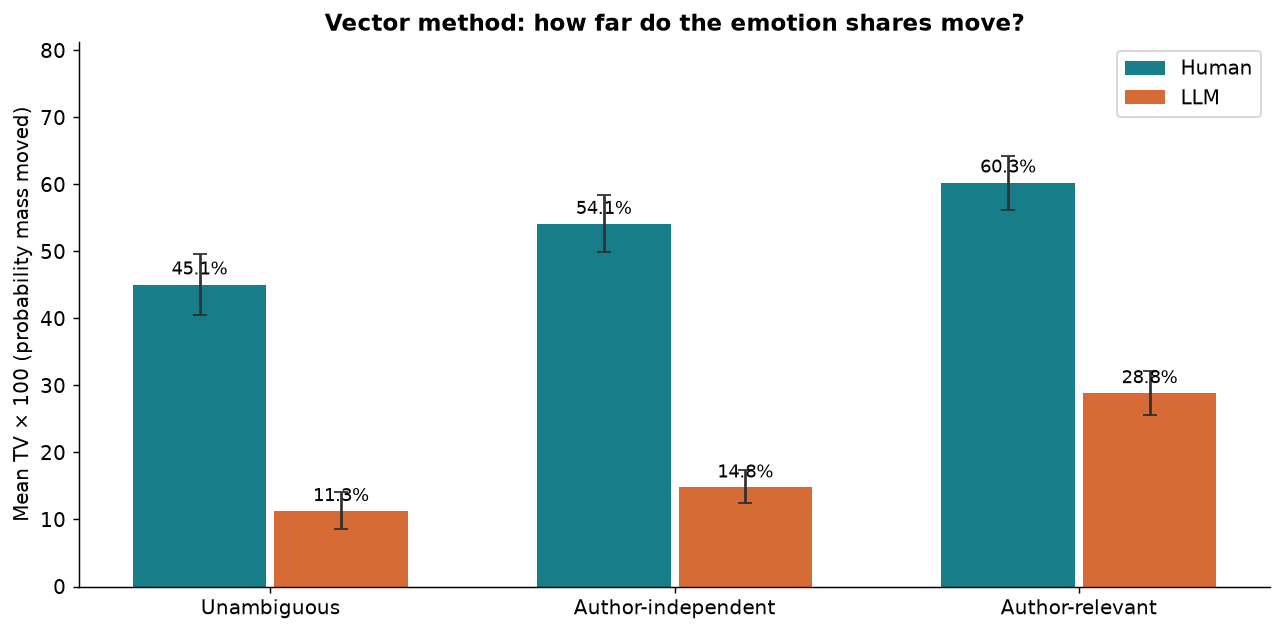

,source,category,comparisons,texts,value_pct,lo_pct,hi_pct
0,Human,author_relevant,200,100,60.283,56.133,64.200
1,Human,author_independent,200,100,54.104,49.857,58.395
2,Human,unambiguous,200,100,45.067,40.583,49.583
3,LLM,author_relevant,1200,100,28.848,25.615,32.091
4,LLM,author_independent,1200,100,14.774,12.445,17.313
5,LLM,unambiguous,1200,100,11.252,8.612,14.047


,source,comparisons,texts,value_pct,lo_pct,hi_pct
0,Human,600,300,53.15,50.60,55.74
1,LLM,3600,300,18.29,16.51,20.15


**Compare with A3:** a label change is yes/no; the shift measures *how much* moved, whether or not the winner changed. These averages still include ordinary rater-to-rater disagreement; the tests in C5 account for it.

In [27]:
vector_rates = bar(study, 'tv', 'vector_TV_by_category', 'Vector method: how far do the emotion shares move?',
                   'Mean TV × 100 (probability mass moved)')
vector_total = summary(study, 'tv', False)
table(vector_total, 'vector_overall_TV', 2)
explain('**Compare with A3:** a label change is yes/no; the shift measures *how much* moved, whether or not '
        'the winner changed. These averages still include ordinary rater-to-rater disagreement; the tests '
        'in C5 account for it.')

## C4. What kind of change happened?

Every comparison falls into exactly one of five kinds: no change; the same emotions with
different percentages; new emotions appear; emotions disappear; both. These describe the
**group's** vote distribution, not individual people changing their minds (different people rated
each version).

In [28]:
EVENT_TYPES = ['No distribution change', 'Same emotions; proportions change', 'Emotions appear only',
               'Emotions disappear only', 'Emotions appear AND disappear']


def events(study):
    """Count the five kinds of change, per source."""
    rows = []
    for src, d in [('Human', study.h), ('LLM', study.l)]:
        for change in EVENT_TYPES:
            flag = d.change == change
            rows.append(dict(source=src, event=change, comparisons=int(flag.sum()), denominator=len(d),
                             percent=100 * flag.mean(),
                             texts_with_event=int(d.loc[flag, 'text_id'].nunique()), text_denominator=300))
    return pd.DataFrame(rows)


def events_plot(study):
    d = events(study)
    fig, ax = plt.subplots(figsize=(11, 5))
    names = d.event.drop_duplicates().tolist()
    y = np.arange(len(names))
    for j, src in enumerate(['Human', 'LLM']):
        q = d[d.source == src]
        ax.barh(y + (j - .5) * .36, q.percent, .34, label=src, color=COLORS[src])
        for yy, (_, r) in zip(y + (j - .5) * .36, q.iterrows()):
            ax.text(r.percent + .5, yy, f'{r.percent:.1f}% ({r.comparisons:,}/{r.denominator:,})',
                    va='center', fontsize=9)
    ax.set_yticks(y, names)
    ax.invert_yaxis()
    ax.set_xlim(0, min(100, d.percent.max() + 26))
    ax.set_xlabel('Share of neutral–persona comparisons (%)')
    ax.set_title('What changed inside the distribution?')
    ax.legend()
    finish(fig, 'vector_change_types')
    table(d, 'vector_change_types')
    return d

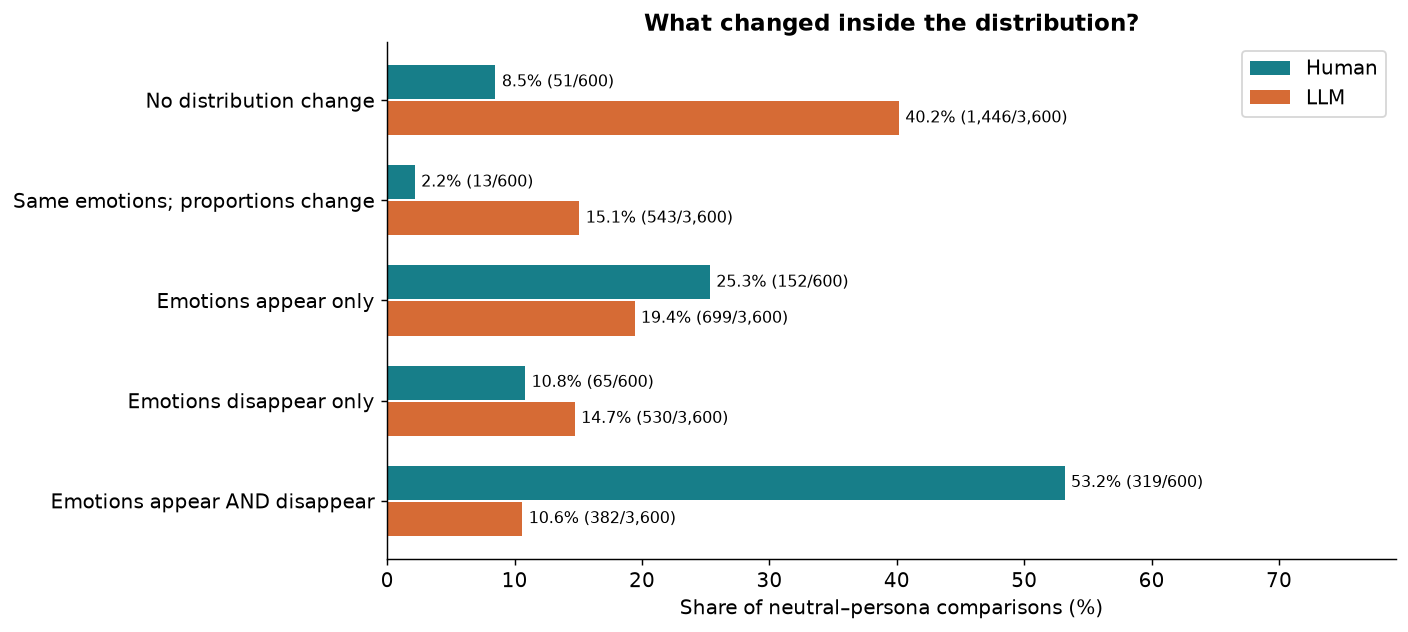

,source,event,comparisons,denominator,percent,texts_with_event,text_denominator
0,Human,No distribution change,51,600,8.500,44,300
1,Human,Same emotions; proportions change,13,600,2.167,13,300
2,Human,Emotions appear only,152,600,25.333,114,300
3,Human,Emotions disappear only,65,600,10.833,57,300
4,Human,Emotions appear AND disappear,319,600,53.167,211,300
5,LLM,No distribution change,1446,3600,40.167,245,300
6,LLM,Same emotions; proportions change,543,3600,15.083,153,300
7,LLM,Emotions appear only,699,3600,19.417,197,300
8,LLM,Emotions disappear only,530,3600,14.722,173,300
9,LLM,Emotions appear AND disappear,382,3600,10.611,112,300


**Human:** 13 of 600 comparisons (2.2%) keep exactly the same emotions but change their percentages (in 13 of 300 texts).

**LLM:** 543 of 3,600 comparisons (15.1%) keep exactly the same emotions but change their percentages (in 153 of 300 texts).

**Careful with counts:** the five kinds add up to 100% of comparisons, but text counts do not, because one text can show different kinds under different personas or prompt set-ups.

In [29]:
event_counts = events_plot(study)
for src in ['Human', 'LLM']:
    r = event_counts[(event_counts.source == src) & (event_counts.event == 'Same emotions; proportions change')].iloc[0]
    explain(f'**{src}:** {int(r.comparisons):,} of {int(r.denominator):,} comparisons ({r.percent:.1f}%) keep exactly '
            f'the same emotions but change their percentages (in {int(r.texts_with_event)} of 300 texts).')
explain('**Careful with counts:** the five kinds add up to 100% of comparisons, but text counts do not, because '
        'one text can show different kinds under different personas or prompt set-ups.')

## C5. H1 and H2 again, now with all the votes

Exactly the same test as A5 (same comparisons, same chance shuffles, same Holm correction), but
measuring the **shift** instead of "did the label change".

For H2 this test picks up changes that **several models share**. If only one model changes in a
comparison, every chance shuffle gives the same shift, so that comparison cannot count as
evidence. Notebook 2 therefore also reports how often each individual model changed.

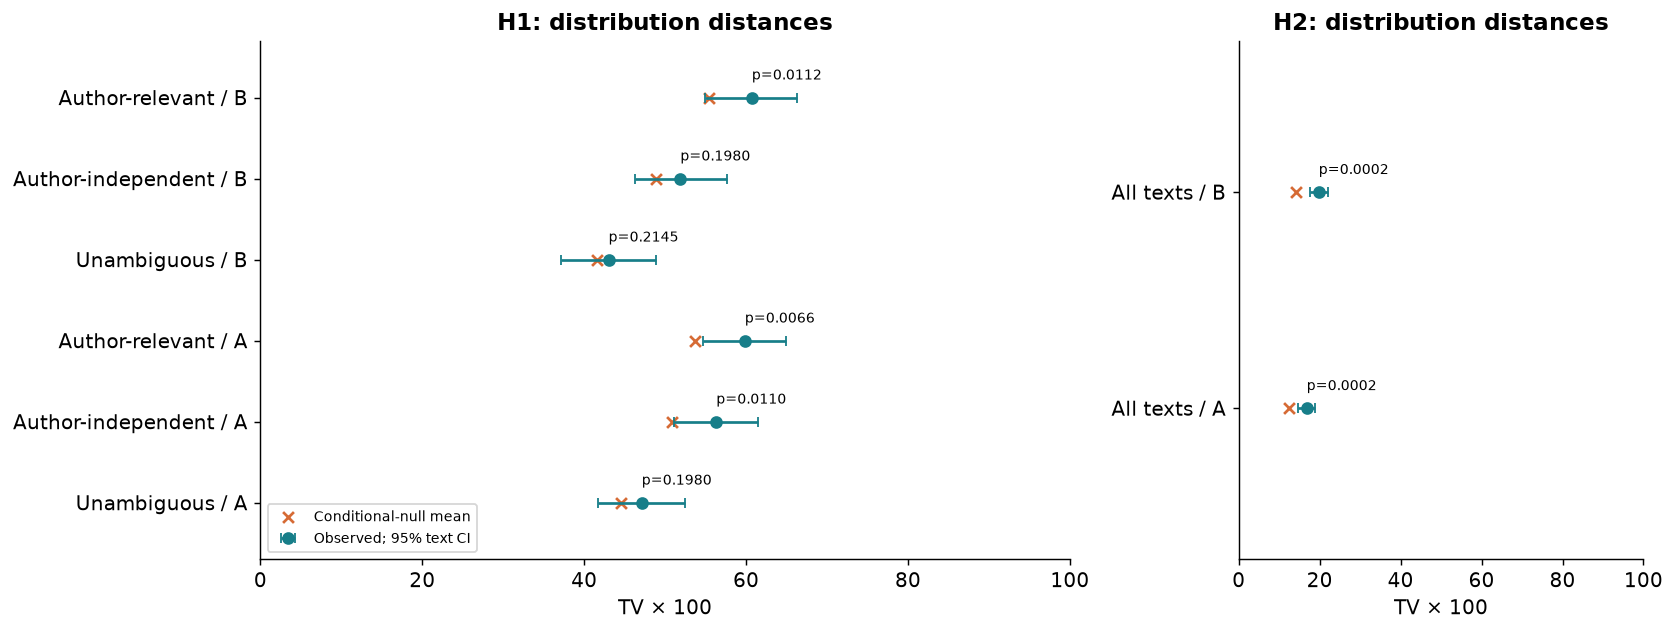

,hypothesis,source,side,category,n_cells,observed_pct,conditional_null_pct,excess_pp,ci_lo,ci_hi,p_raw,p_holm,reject_05
0,H1,Human,a,unambiguous,100,47.117,44.545,2.571,41.750,52.500,0.06599,0.198,False
1,H1,Human,a,author_independent,100,56.324,50.894,5.430,51.040,61.517,0.0022,0.011,True
2,H1,Human,a,author_relevant,100,59.850,53.729,6.121,54.667,64.933,0.0011,0.006599,True
3,H1,Human,b,unambiguous,100,43.017,41.596,1.421,37.100,48.850,0.2145,0.2145,False
4,H1,Human,b,author_independent,100,51.883,48.907,2.976,46.233,57.617,0.06789,0.198,False
5,H1,Human,b,author_relevant,100,60.717,55.442,5.275,54.983,66.233,0.0028,0.0112,True
6,H2,LLM,a,all,1800,16.803,12.330,4.473,14.745,18.969,9.999e-05,0.0002,True
7,H2,LLM,b,all,1800,19.780,14.187,5.593,17.501,22.079,9.999e-05,0.0002,True


**H1, vector method:** 3 of 6 tests are significant after correction.

**H2, vector method:** 2 of 2 tests are significant after correction.

**What it means:** with all the votes, human framing effects are detected for author-relevant texts (both personas) and for one persona on author-independent texts; none for clear texts. The old method detected none of these. Models are affected under both personas.

In [30]:
vector_h12 = plot_h1_h2(study, 'tv', 'vector_H1_H2')
for hyp in ['H1', 'H2']:
    q = vector_h12[vector_h12.hypothesis == hyp]
    explain(f'**{hyp}, vector method:** {q.reject_05.sum()} of {len(q)} tests are significant after correction.')
explain('**What it means:** with all the votes, human framing effects are detected for author-relevant texts '
        '(both personas) and for one persona on author-independent texts; none for clear texts. The old '
        'method detected none of these. Models are affected under both personas.')

## C6. H3 again: raw, and after allowing for chance

Ambiguous texts have raters who disagree more to begin with, so even with no persona effect their
votes would shift more between versions. `test_h3` therefore reports two versions:
- **Raw:** compare the observed shifts (the main test).
- **Conditional-null referenced:** first subtract what chance alone gives for that same text,
  then compare what is left. This was added after the raw result was known, so it is a
  **sensitivity check**, reported next to the raw test and not instead of it.

,analysis,contrast,difference_pp,ci_lo,ci_hi,p_raw,p_holm
0,Raw,Author-relevant minus Author-independent,6.180,0.297,12.084,0.0403,0.0403
1,Raw,Author-independent minus Unambiguous,9.037,2.631,15.325,0.007199,0.0144
2,Raw,Author-relevant minus Unambiguous,15.217,9.083,21.292,9.999e-05,0.0003
3,Conditional-null referenced,Author-relevant minus Author-independent,1.495,-3.260,6.243,0.5273,0.6971
4,Conditional-null referenced,Author-independent minus Unambiguous,2.207,-2.340,6.806,0.3486,0.6971
5,Conditional-null referenced,Author-relevant minus Unambiguous,3.702,-0.603,7.957,0.09559,0.2868


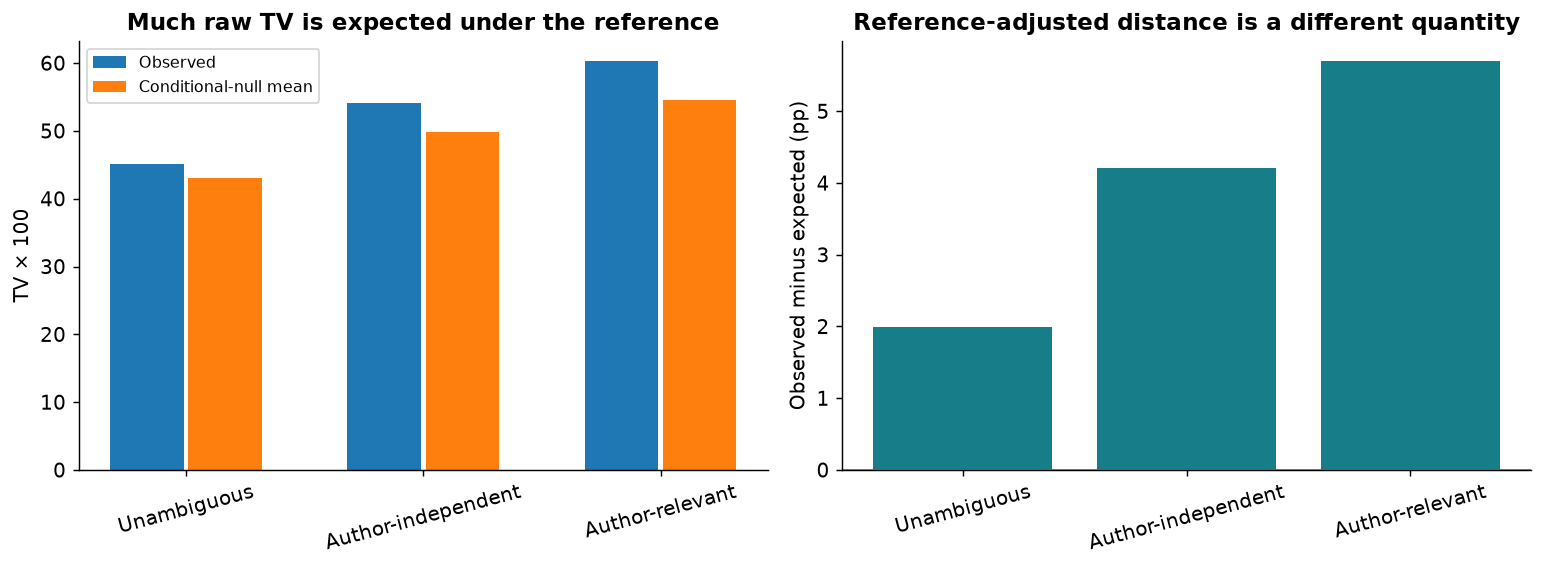

,category,tv,expected,excess
0,unambiguous,45.07,43.07,2.0
1,author_independent,54.10,49.90,4.2
2,author_relevant,60.28,54.59,5.7


**Raw, author-relevant minus author-independent:** 6.18 points, range [0.30, 12.08], corrected p = 0.0403. Significant.

**Conditional-null referenced, author-relevant minus author-independent:** 1.49 points, range [-3.26, 6.24], corrected p = 0.6971. Not significant.

**What it means:** the main test says author-relevant texts shift more, but the sensitivity check does not. So the H3 result depends on the reference used and should not be called simply "supported". "Not significant" also does not prove the groups are equal.

In [31]:
vector_h3, vector_h3_text = test_h3(study, 'tv')
table(vector_h3, 'vector_H3_raw_and_referenced')
reference = vector_h3_text.groupby('category')[['tv', 'expected', 'excess']].mean().reindex(CATS) * 100
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for j, col in enumerate(['tv', 'expected']):
    axes[0].bar(np.arange(3) + (j - .5) * .33, reference[col], .31, label=['Observed', 'Conditional-null mean'][j])
axes[0].set_xticks(range(3), CAT_NAMES, rotation=15)
axes[0].set_ylabel('TV × 100')
axes[0].set_title('Much raw TV is expected under the reference')
axes[0].legend(fontsize=9)
axes[1].bar(CAT_NAMES, reference.excess, color='#177e89')
axes[1].tick_params(axis='x', rotation=15)
axes[1].axhline(0, color='grey')
axes[1].set_ylabel('Observed minus expected (pp)')
axes[1].set_title('Reference-adjusted distance is a different quantity')
finish(fig, 'vector_H3_reference')
table(reference.reset_index(), 'vector_H3_category_reference', 2)
for mode in ['Raw', 'Conditional-null referenced']:
    r = vector_h3[vector_h3.analysis == mode].iloc[0]
    explain(f'**{mode}, author-relevant minus author-independent:** {r.difference_pp:.2f} points, '
            f'range [{r.ci_lo:.2f}, {r.ci_hi:.2f}], corrected p = {r.p_holm:.4f}. '
            + ('Significant.' if r.p_holm < .05 else 'Not significant.'))
explain('**What it means:** the main test says author-relevant texts shift more, but the sensitivity check '
        'does not. So the H3 result depends on the reference used and should not be called simply '
        '"supported". "Not significant" also does not prove the groups are equal.')

## C7. H4 again: size and direction, now measured separately

- **Size:** for each text, the average human shift minus the average model shift.
- **Direction** (`direction`): the **shift vector** is persona shares minus neutral shares (for
  example fear +67, anger −33, sadness −33). The cosine compares the human and model shift vectors
  for the same text, persona and prompt set-up: +1 same direction, 0 unrelated, −1 opposite. If
  either side did not move there is no direction, and that comparison is left out (never counted
  as zero). Chance: pair each text's human shifts with a random other text's model shifts.

In [32]:
def direction(study, n_perm=N_RANDOM):
    """H4 direction. For each text, persona and prompt set-up: cosine between the human shift
    vector and the model shift vector (persona sides kept separate, never averaged).
    Comparisons where either side did not move have no direction and are left out.
    Chance: pair each text's human shifts with another random text's model shifts, 10,000 times."""
    h_index = study.h.set_index(['text_id', 'side'])
    l_index = study.l.set_index(['text_id', 'side', 'config'])
    hd = np.stack([h_index.loc[(tid, side), 'delta'] for tid in study.ids
                   for side in ['a', 'b']]).reshape(300, 2, 11)
    ld = np.stack([l_index.loc[(tid, side, pv + '/' + lf), 'delta'] for tid in study.ids
                   for side in ['a', 'b'] for pv, lf in study.configs]).reshape(300, 2, 6, 11)
    hs = np.repeat(hd[:, :, None, :], 6, axis=2)       # same human shift for all 6 set-ups
    cos = cosine(hs, ld)
    mask = np.isfinite(cos)
    sums = np.nansum(cos, axis=(1, 2))
    counts = mask.sum(axis=(1, 2))
    obs = sums.sum() / counts.sum()
    rng = np.random.default_rng(301)
    idx = rng.integers(0, 300, (N_RANDOM, 300))
    boot = sums[idx].sum(axis=1) / counts[idx].sum(axis=1)
    lo, hi = np.quantile(boot, [.025, .975])
    null = np.empty(n_perm)
    for b in range(n_perm):
        perm = rng.permutation(300)
        null[b] = np.nanmean(cosine(hs, ld[perm]))
    p = (1 + (null >= obs - 1e-12).sum()) / (n_perm + 1)
    return pd.DataFrame([dict(mean_cosine=obs, ci_lo=lo, ci_hi=hi, defined_comparisons=int(mask.sum()),
                              all_comparisons=3600, texts_with_any_defined=int((counts > 0).sum()),
                              null_mean=float(null.mean()), p_permutation=p)]), cos, null

,metric,n_texts,human_mean_pct,llm_mean_pct,human_minus_llm_pp,ci_lo,ci_hi
0,tv,300,53.151,18.291,34.86,32.233,37.539


,mean_cosine,ci_lo,ci_hi,defined_comparisons,all_comparisons,texts_with_any_defined,null_mean,p_permutation
0,0.112,0.072,0.152,2020,3600,252,0.006,9.999e-05


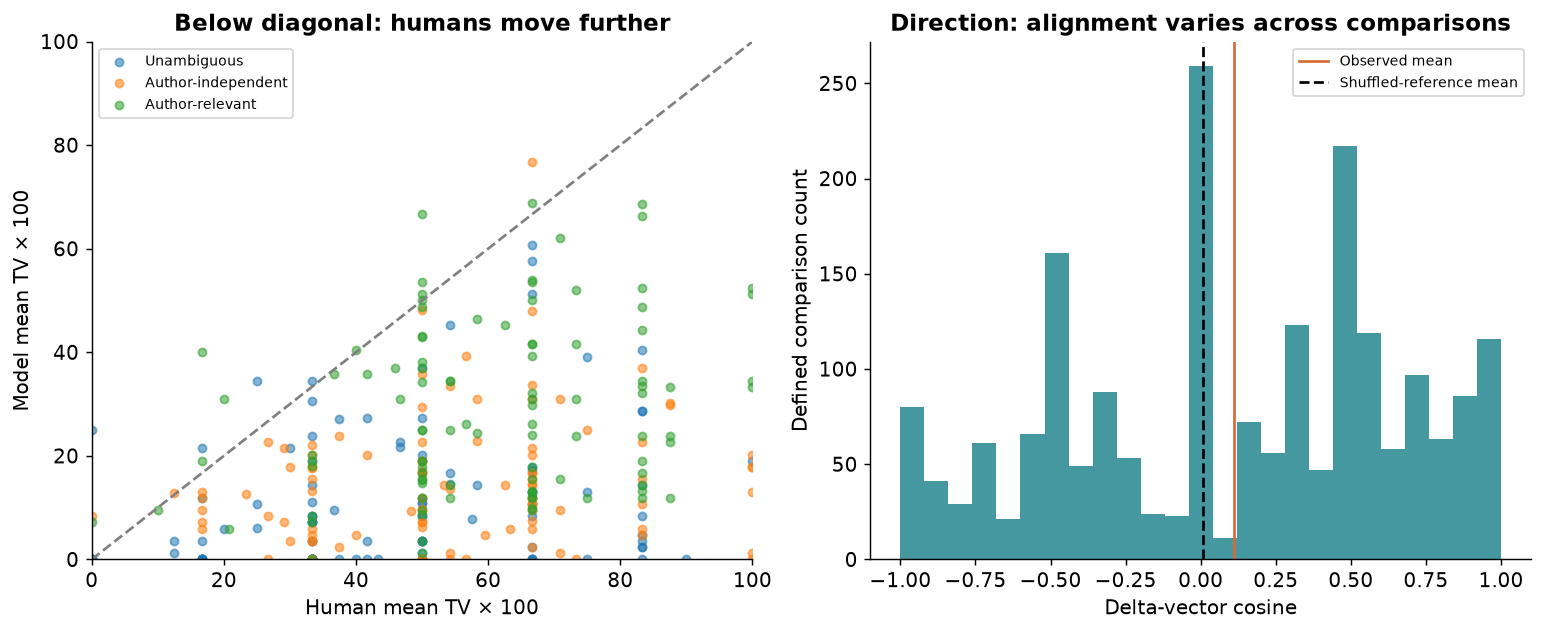

**Size:** people shift 34.86 points more than models (range [32.23, 37.54]). **Direction:** average cosine 0.112 (range [0.072, 0.152]) against about 0.006 by chance, p = 0.0001; measurable in 2,020 of 3,600 comparisons. Models lean the same way as people more than chance, but only slightly. Notebook 2 checks whether the size gap survives giving both sides the same number of votes.

In [33]:
vector_h4 = h4_size(study, 'tv')
table(vector_h4, 'vector_H4_magnitude')
direction_result, cosines, direction_null = direction(study)
table(direction_result, 'vector_H4_direction')
hv = study.h.groupby('text_id').tv.mean().reindex(study.ids) * 100
lv = study.l.groupby('text_id').tv.mean().reindex(study.ids) * 100
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for cat in CATS:
    mask = np.array([study.category[t] == cat for t in study.ids])
    axes[0].scatter(hv[mask], lv[mask], s=20, alpha=.55, label=CAT_NAME[cat])
axes[0].plot([0, 100], [0, 100], '--', color='grey')
axes[0].set(xlim=(0, 100), ylim=(0, 100), xlabel='Human mean TV × 100', ylabel='Model mean TV × 100',
            title='Below diagonal: humans move further')
axes[0].legend(fontsize=8)
axes[1].hist(cosines[np.isfinite(cosines)], bins=25, color='#177e89', alpha=.8)
axes[1].axvline(direction_result.iloc[0].mean_cosine, color='#d66b35', label='Observed mean')
axes[1].axvline(direction_result.iloc[0].null_mean, color='black', ls='--', label='Shuffled-reference mean')
axes[1].set(xlabel='Delta-vector cosine', ylabel='Defined comparison count',
            title='Direction: alignment varies across comparisons')
axes[1].legend(fontsize=8)
finish(fig, 'vector_H4_magnitude_direction')
r = vector_h4.iloc[0]
dr = direction_result.iloc[0]
explain(f'**Size:** people shift {r.human_minus_llm_pp:.2f} points more than models (range [{r.ci_lo:.2f}, {r.ci_hi:.2f}]). '
        f'**Direction:** average cosine {dr.mean_cosine:.3f} (range [{dr.ci_lo:.3f}, {dr.ci_hi:.3f}]) against about '
        f'{dr.null_mean:.3f} by chance, p = {dr.p_permutation:.4f}; measurable in {int(dr.defined_comparisons):,} of 3,600 '
        'comparisons. Models lean the same way as people more than chance, but only slightly. Notebook 2 checks '
        'whether the size gap survives giving both sides the same number of votes.')

# Part D: Old method vs vector method

The old method counts label switches; the vector method measures how far and where the votes
move. Their percentages mean different things, so they are compared side by side, never
subtracted.

In [34]:
comparison = old_h12[['hypothesis', 'category', 'side', 'observed_pct', 'p_holm', 'reject_05']].merge(
    vector_h12[['hypothesis', 'category', 'side', 'observed_pct', 'p_holm', 'reject_05']],
    on=['hypothesis', 'category', 'side'], suffixes=('_label', '_vector'), validate='one_to_one')
table(comparison, 'old_vs_vector_H1_H2')
n_h1_vec = int(vector_h12.query("hypothesis == 'H1'").reject_05.sum())
n_h2_vec = int(vector_h12.query("hypothesis == 'H2'").reject_05.sum())
final_summary = pd.DataFrame([
    {'question': 'H1', 'old': 'Selected-label switch frequency', 'vector': 'Full-distribution TV against conditional null',
     'conclusion': f'{n_h1_vec}/6 vector tests reject; interpret by category and side; controls not proven null'},
    {'question': 'H2', 'old': 'Selected ensemble-label switches', 'vector': 'Net redistribution under paired model swaps',
     'conclusion': f'{n_h2_vec}/2 vector tests reject; coordination and individual changes remain distinct'},
    {'question': 'H3', 'old': f'Raw AR−AI label-rate p={old_h3_raw.iloc[0].p_holm:.4f}',
     'vector': f'Raw AR−AI p={vector_h3.iloc[0].p_holm:.4f}; referenced p={vector_h3.iloc[3].p_holm:.4f}',
     'conclusion': 'Evaluate the direct contrast under both references; raw ordering alone is insufficient'},
    {'question': 'H4 magnitude', 'old': f'Frequency gap {old_h4.iloc[0].human_minus_llm_pp:.2f}pp',
     'vector': f'TV gap {vector_h4.iloc[0].human_minus_llm_pp:.2f}pp',
     'conclusion': 'Different constructs; count and sampling-process sensitivity still matters'},
    {'question': 'H4 direction', 'old': 'Exact selected-label transition proxy',
     'vector': f'Delta cosine {direction_result.iloc[0].mean_cosine:.3f}, with explicit coverage',
     'conclusion': 'Partial resemblance is conditional; no averaging away opposing personas'},
    {'question': 'What was hidden?', 'old': 'A stable label is recorded as no change',
     'vector': 'Separates unchanged, proportion changes, appearances and disappearances',
     'conclusion': 'The information-loss and event tables provide the direct counts'}])
table(final_summary, 'final_method_comparison')
plain_verdicts = pd.DataFrame([
    {'hypothesis': 'H1 — humans', 'old_method': 'No adjusted selected-label tests reject in this run',
     'vector_method': 'Qualified partial support: author-relevant A and B, and author-independent A reject',
     'meaning': 'Full distributions detect differences the selected-label statistic misses; control non-rejection is not absence'},
    {'hypothesis': 'H2 — models', 'old_method': 'Both paired selected-label tests reject',
     'vector_method': 'Both paired-TV coordination tests reject',
     'meaning': 'Conditional support; single generations and joint exchangeability limit attribution'},
    {'hypothesis': 'H3 — author relevance', 'old_method': 'Direct AR−AI label-frequency contrast does not reject',
     'vector_method': 'Raw contrast rejects; conditional-null-referenced contrast does not',
     'meaning': 'The stronger category-sensitivity claim is not robust to the reference'},
    {'hypothesis': 'H4 — resemblance', 'old_method': 'Frequency differs; categorical transition proxy exceeds shuffled pairing',
     'vector_method': 'Larger human TV; small positive directional correspondence',
     'meaning': 'Qualified partial resemblance; count sensitivity follows in Notebook 2'}])
# These checks stop the notebook if a future data change would make the verdict text above wrong.
assert old_h12[old_h12.hypothesis == 'H1'].reject_05.sum() == 0
assert vector_h12[vector_h12.hypothesis == 'H1'].reject_05.sum() == 3
assert old_h12[old_h12.hypothesis == 'H2'].reject_05.all() and vector_h12[vector_h12.hypothesis == 'H2'].reject_05.all()
assert old_h3_raw.iloc[0].p_holm >= .05 and vector_h3.iloc[0].p_holm < .05 and vector_h3.iloc[3].p_holm >= .05
assert old_direction.iloc[0].p_permutation < .05 and direction_result.iloc[0].p_permutation < .05
assert old_h4.iloc[0].ci_lo > 0 and vector_h4.iloc[0].ci_lo > 0
table(plain_verdicts, 'plain_language_hypothesis_verdicts')

,hypothesis,category,side,observed_pct_label,p_holm_label,reject_05_label,observed_pct_vector,p_holm_vector,reject_05_vector
0,H1,unambiguous,a,38.000,1,False,47.117,0.198,False
1,H1,author_independent,a,58.000,0.2568,False,56.324,0.011,True
2,H1,author_relevant,a,60.000,1,False,59.850,0.006599,True
3,H1,unambiguous,b,40.000,1,False,43.017,0.2145,False
4,H1,author_independent,b,57.000,0.5484,False,51.883,0.198,False
5,H1,author_relevant,b,64.000,1,False,60.717,0.0112,True
6,H2,all,a,16.000,0.0002,True,16.803,0.0002,True
7,H2,all,b,20.778,0.0002,True,19.780,0.0002,True


,question,old,vector,conclusion
0,H1,Selected-label switch frequency,Full-distribution TV against conditional null,3/6 vector tests reject; interpret by category...
1,H2,Selected ensemble-label switches,Net redistribution under paired model swaps,2/2 vector tests reject; coordination and indi...
2,H3,Raw AR−AI label-rate p=0.4721,Raw AR−AI p=0.0403; referenced p=0.6971,Evaluate the direct contrast under both refere...
3,H4 magnitude,Frequency gap 34.44pp,TV gap 34.86pp,Different constructs; count and sampling-proce...
4,H4 direction,Exact selected-label transition proxy,"Delta cosine 0.112, with explicit coverage",Partial resemblance is conditional; no averagi...
5,What was hidden?,A stable label is recorded as no change,"Separates unchanged, proportion changes, appea...",The information-loss and event tables provide ...


,hypothesis,old_method,vector_method,meaning
0,H1 — humans,No adjusted selected-label tests reject in thi...,Qualified partial support: author-relevant A a...,Full distributions detect differences the sele...
1,H2 — models,Both paired selected-label tests reject,Both paired-TV coordination tests reject,Conditional support; single generations and jo...
2,H3 — author relevance,Direct AR−AI label-frequency contrast does not...,Raw contrast rejects; conditional-null-referen...,The stronger category-sensitivity claim is not...
3,H4 — resemblance,Frequency differs; categorical transition prox...,Larger human TV; small positive directional co...,Qualified partial resemblance; count sensitivi...


## D2. What this notebook shows

| | Old method (one label) | Vector method (all votes) | Verdict |
|---|---|---|---|
| **H1** humans | 0 of 6 tests significant | 3 of 6: author-relevant A and B, author-independent A | Partially supported |
| **H2** models | 2 of 2 | 2 of 2 | Supported at the ensemble level |
| **H3** | no difference detected | raw test significant; chance-adjusted check not | Weak / not robust |
| **H4** | people change far more often; same switch more than chance | people shift far more; direction slightly aligned | Qualified support |

**The main point.** Keeping all the votes does two things. It **detects** human framing effects
that a one-label analysis misses, and it **shows** where an apparently strong result (H3) is not
robust once chance is taken into account.

**Limits to keep in mind**
- Each human version was rated by different people; each model answered both versions itself.
- Each model gave one answer per condition, so a model's own randomness is not measured.
- People rated about 30 texts each, but who rated what was not kept.
- The author-relevant group was defined with a pilot persona test.
- The extra analyses (H3 sensitivity check, Notebook 2) were added after the main tests.
  "Not significant" never proves "no effect".

**Next:** Notebook 2 looks at *what* moved inside the vote distributions.